# YOLO26 Vessel Detection Experiments with SAHI

**Variables tested:**
- Image size: 512, 640, 768, 1024
- Epochs: 50, 100, 150, 200
- Model size: nano, small, medium, large
- SAHI inference: Compare standard vs SAHI inference for each trained model

## 1. Setup and Configuration

In [1]:
# Install packages if needed (run once, then restart kernel)
import sys
!{sys.executable} -m pip install --user numpy==1.26.4 pandas ultralytics sahi matplotlib --quiet

    matplotlib (>=3.0.*)
                ~~~~~~^
    opencv-python (>=3.) ; extra == 'all'
                  ~~~~^
    extract-msg (<=0.29.*)
                 ~~~~~~~^


In [2]:
from ultralytics import YOLO
import torch
import time
import gc
import json
from datetime import datetime
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Verify GPU is available
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Training will be very slow.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA B200
GPU Memory: 191.5 GB


In [3]:
# Check SAHI installation
try:
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction, get_prediction
    SAHI_AVAILABLE = True
    print("SAHI installed and ready")
except ImportError:
    SAHI_AVAILABLE = False
    print("SAHI not installed. Run: pip install sahi")
    print(" SAHI evaluation will be skipped.")

SAHI installed and ready


In [4]:
# Point to the SLICED dataset (which you have) instead of the original
data_yaml_path = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml"

val_images_dir = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/images/val"

val_labels_dir = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/labels/val"

progress_file = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/experiment_progress.json"

In [ ]:
## Checking the size of the boat annotations

Jupiter Inlet — Vessel Size Analysis
All vessel annotations: 3004
  Area      — min: 18  max: 18011  mean: 646  median: 253
  Width     — min: 4  max: 248  mean: 29  median: 20
  Height    — min: 4  max: 94  mean: 16  median: 13
  √Area     — min: 4.3  max: 134.2  mean: 20.9

COCO size breakdown:
  Small  (<32×32px):   2461  (81.9%)
  Medium (32–96px):     535  (17.8%)
  Large  (>96×96px):      8  (0.3%)


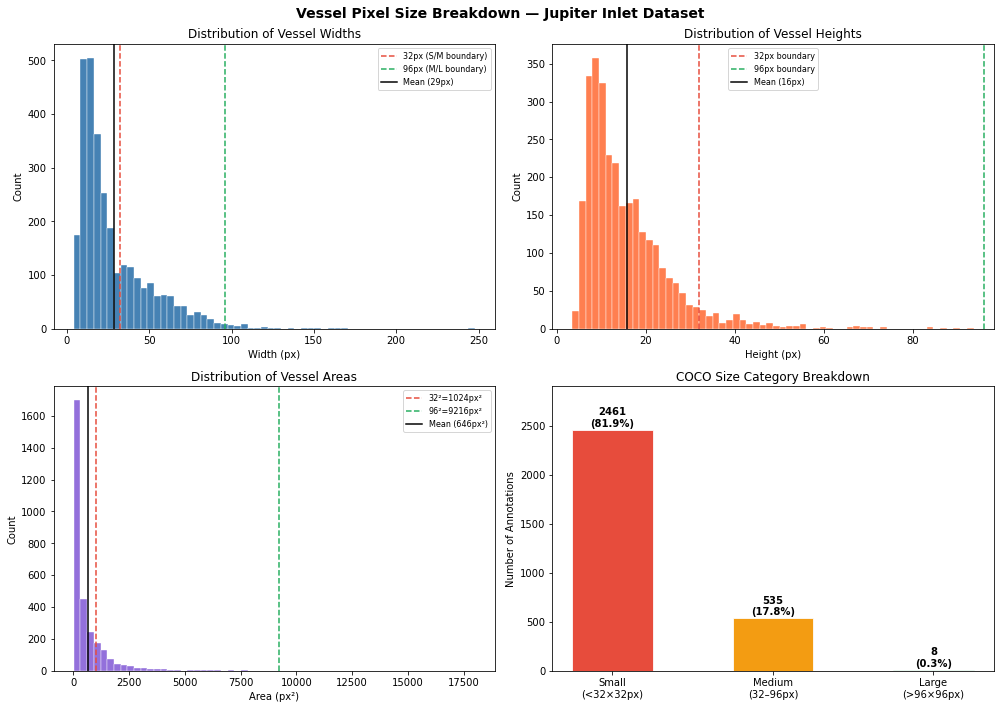

Saved: vessel_size_breakdown.png


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

JI_GT_JSON = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/_annotations.coco.json"

with open(JI_GT_JSON) as f:
    ji_gt = json.load(f)

for ann in ji_gt['annotations']:
    ann['bbox'] = [float(x) for x in ann['bbox']]

all_areas   = [float(a['bbox'][2]) * float(a['bbox'][3]) for a in ji_gt['annotations']]
all_widths  = [float(a['bbox'][2]) for a in ji_gt['annotations']]
all_heights = [float(a['bbox'][3]) for a in ji_gt['annotations']]
all_sqrts   = [float(a**0.5) for a in all_areas]  # sqrt(area) = 'effective side'

small  = sum(1 for a in all_areas if a < 32*32)
medium = sum(1 for a in all_areas if 32*32 <= a < 96*96)
large  = sum(1 for a in all_areas if a >= 96*96)
total  = len(all_areas)

print("Jupiter Inlet — Vessel Size Analysis")
print(f"All vessel annotations: {total}")
print(f"  Area      — min: {min(all_areas):.0f}  max: {max(all_areas):.0f}  mean: {np.mean(all_areas):.0f}  median: {np.median(all_areas):.0f}")
print(f"  Width     — min: {min(all_widths):.0f}  max: {max(all_widths):.0f}  mean: {np.mean(all_widths):.0f}  median: {np.median(all_widths):.0f}")
print(f"  Height    — min: {min(all_heights):.0f}  max: {max(all_heights):.0f}  mean: {np.mean(all_heights):.0f}  median: {np.median(all_heights):.0f}")
print(f"  √Area     — min: {min(all_sqrts):.1f}  max: {max(all_sqrts):.1f}  mean: {np.mean(all_sqrts):.1f}")
print(f"\nCOCO size breakdown:")
print(f"  Small  (<32×32px):   {small:4d}  ({small/total*100:.1f}%)")
print(f"  Medium (32–96px):    {medium:4d}  ({medium/total*100:.1f}%)")
print(f"  Large  (>96×96px):   {large:4d}  ({large/total*100:.1f}%)")

# ── Pixel size breakdown plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Vessel Pixel Size Breakdown — Jupiter Inlet Dataset', fontsize=14, fontweight='bold')

COLORS = {'Small': '#e74c3c', 'Medium': '#f39c12', 'Large': '#27ae60'}

# 1. Width histogram
ax = axes[0, 0]
ax.hist(all_widths, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(32,  color='#e74c3c', linestyle='--', linewidth=1.5, label='32px (S/M boundary)')
ax.axvline(96,  color='#27ae60', linestyle='--', linewidth=1.5, label='96px (M/L boundary)')
ax.axvline(np.mean(all_widths), color='black', linestyle='-', linewidth=1.5, label=f'Mean ({np.mean(all_widths):.0f}px)')
ax.set_xlabel('Width (px)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Vessel Widths')
ax.legend(fontsize=8)

# 2. Height histogram
ax = axes[0, 1]
ax.hist(all_heights, bins=60, color='coral', edgecolor='white', linewidth=0.4)
ax.axvline(32,  color='#e74c3c', linestyle='--', linewidth=1.5, label='32px boundary')
ax.axvline(96,  color='#27ae60', linestyle='--', linewidth=1.5, label='96px boundary')
ax.axvline(np.mean(all_heights), color='black', linestyle='-', linewidth=1.5, label=f'Mean ({np.mean(all_heights):.0f}px)')
ax.set_xlabel('Height (px)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Vessel Heights')
ax.legend(fontsize=8)

# 3. Area histogram (log-scale x)
ax = axes[1, 0]
ax.hist(all_areas, bins=60, color='mediumpurple', edgecolor='white', linewidth=0.4)
ax.axvline(32*32,  color='#e74c3c', linestyle='--', linewidth=1.5, label=f'32²={32*32}px²')
ax.axvline(96*96,  color='#27ae60', linestyle='--', linewidth=1.5, label=f'96²={96*96}px²')
ax.axvline(np.mean(all_areas), color='black', linestyle='-', linewidth=1.5, label=f'Mean ({np.mean(all_areas):.0f}px²)')
ax.set_xlabel('Area (px²)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Vessel Areas')
ax.legend(fontsize=8)

# 4. COCO size category bar chart
ax = axes[1, 1]
categories = ['Small\n(<32×32px)', 'Medium\n(32–96px)', 'Large\n(>96×96px)']
counts     = [small, medium, large]
pcts       = [f'{c/total*100:.1f}%' for c in counts]
bar_colors = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax.bar(categories, counts, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
for bar, pct, cnt in zip(bars, pcts, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{cnt}\n({pct})', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Annotations')
ax.set_title('COCO Size Category Breakdown')
ax.set_ylim(0, max(counts) * 1.18)

plt.tight_layout()
plt.savefig('vessel_size_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vessel_size_breakdown.png")


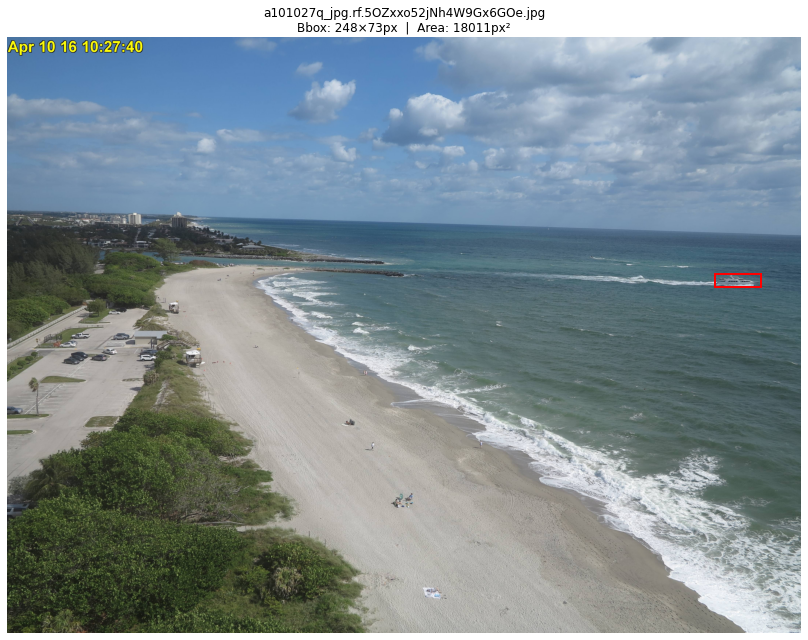

OSError: image file is truncated (20 bytes not processed)

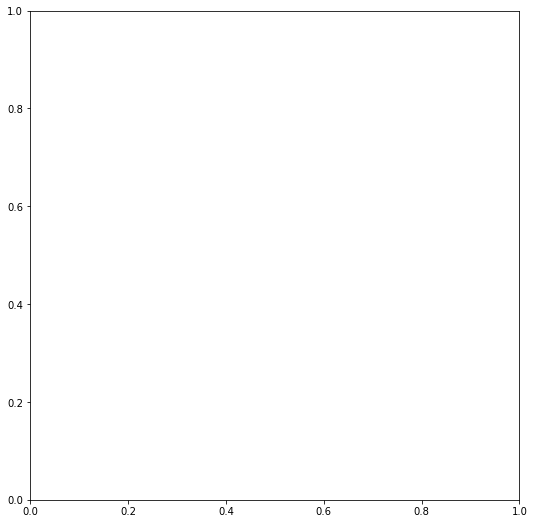

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Find top 5 largest annotations
sorted_anns = sorted(ji_gt['annotations'], 
                     key=lambda a: float(a['bbox'][2]) * float(a['bbox'][3]), 
                     reverse=True)[:5]

# Map image id to filename
id_to_file = {img['id']: img['file_name'] for img in ji_gt['images']}

JI_IMAGE_FOLDER = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet"

for ann in sorted_anns:
    img_file = id_to_file[ann['image_id']]
    img_path = os.path.join(JI_IMAGE_FOLDER, img_file)
    
    if not os.path.exists(img_path):
        print(f"Not found: {img_path}")
        continue

    img = Image.open(img_path)
    x, y, w, h = [float(v) for v in ann['bbox']]
    area = w * h

    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(img)
    rect = patches.Rectangle((x, y), w, h, 
                               linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"{img_file}\nBbox: {w:.0f}×{h:.0f}px  |  Area: {area:.0f}px²")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## 2. SAHI Window Pre-Processing for Training
1. `slice_dataset()` — cuts train/val images+labels into 1024px tiles with 50% overlap
2. `write_sliced_data_yaml()` — writes a new `data.yaml` pointing to the tiled dataset
3. Training uses `imgsz=1024` on the tiled images
4. Inference uses SAHI with `slice_size=1024` to match training windows

In [7]:
from pathlib import Path
import shutil, yaml
from PIL import Image
import numpy as np

# Baseline configurations
SLICE_SIZE       = 1024   # Window size 
SLICE_OVERLAP    = 0.5    
MIN_VISIBILITY   = 0.3    

# OG yolo dataset
ORIG_DATASET_ROOT = Path(data_yaml_path).parent

# Where the tiled dataset will be written
SLICED_DATASET_ROOT = ORIG_DATASET_ROOT.parent / f'jupiter_inlet_yolo_sliced_{SLICE_SIZE}'

# 
def _xywhn_to_xyxy(cx, cy, bw, bh, img_w, img_h):
    """YOLO normalised cx,cy,w,h → pixel x1,y1,x2,y2."""
    x1 = (cx - bw/2) * img_w;  x2 = (cx + bw/2) * img_w
    y1 = (cy - bh/2) * img_h;  y2 = (cy + bh/2) * img_h
    return x1, y1, x2, y2


def _xyxy_to_xywhn(x1, y1, x2, y2, tile_w, tile_h):
    """Pixel x1,y1,x2,y2 → YOLO normalised cx,cy,w,h relative to tile."""
    cx = ((x1 + x2) / 2) / tile_w
    cy = ((y1 + y2) / 2) / tile_h
    bw = (x2 - x1) / tile_w
    bh = (y2 - y1) / tile_h
    return cx, cy, bw, bh


def slice_image_and_labels(img_path, label_path, out_img_dir, out_lbl_dir,
                            slice_size=1024, overlap=0.2, min_visibility=0.3):
    """
    Slice one image into overlapping tiles and re-project YOLO labels.
    Returns number of tiles saved.
    """
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    step = int(slice_size * (1 - overlap))

    # Load ground-truth labels
    gt_rows = []
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                    gt_rows.append((cls, cx, cy, bw, bh))

    stem   = Path(img_path).stem
    n_saved = 0

    xs = list(range(0, max(1, W - slice_size), step)) + [max(0, W - slice_size)]
    ys = list(range(0, max(1, H - slice_size), step)) + [max(0, H - slice_size)]

    for y0 in sorted(set(ys)):
        for x0 in sorted(set(xs)):
            x1t, y1t = x0, y0
            x2t, y2t = min(x0 + slice_size, W), min(y0 + slice_size, H)
            tw, th = x2t - x1t, y2t - y1t

            tile_labels = []
            for cls, cx, cy, bw, bh in gt_rows:
                # Convert full-image label to pixel coords
                bx1, by1, bx2, by2 = _xywhn_to_xyxy(cx, cy, bw, bh, W, H)

                # Clip to tile
                cx1 = max(bx1, x1t);  cy1 = max(by1, y1t)
                cx2 = min(bx2, x2t);  cy2 = min(by2, y2t)

                if cx2 <= cx1 or cy2 <= cy1:
                    continue  # No overlap

                # Visibility check
                orig_area = max((bx2-bx1)*(by2-by1), 1e-6)
                clip_area = (cx2-cx1)*(cy2-cy1)
                if clip_area / orig_area < min_visibility:
                    continue

                # Convert clipped box → tile-relative YOLO format
                ncx, ncy, nbw, nbh = _xyxy_to_xywhn(
                    cx1-x1t, cy1-y1t, cx2-x1t, cy2-y1t, tw, th)
                tile_labels.append(f'{cls} {ncx:.6f} {ncy:.6f} {nbw:.6f} {nbh:.6f}')

            # Save tile image
            tile_img  = img.crop((x1t, y1t, x2t, y2t))
            tile_name = f'{stem}_x{x1t}_y{y1t}'
            tile_img.save(out_img_dir / f'{tile_name}.jpg', quality=95)

            # Save tile label (even if empty — YOLO expects label files)
            with open(out_lbl_dir / f'{tile_name}.txt', 'w') as f:
                f.write('\n'.join(tile_labels))

            n_saved += 1

    return n_saved


def slice_dataset(orig_root, out_root, splits=('train', 'val'),
                  slice_size=1024, overlap=0.2, min_visibility=0.3):
    """
    Slice all images in train/ and val/ splits.
    Skips re-slicing if output already exists (safe to re-run).
    """
    out_root = Path(out_root)

    for split in splits:
        img_in_dir = Path(orig_root) / 'images' / split
        lbl_in_dir = Path(orig_root) / 'labels' / split

        img_out_dir = out_root / 'images' / split
        lbl_out_dir = out_root / 'labels' / split
        img_out_dir.mkdir(parents=True, exist_ok=True)
        lbl_out_dir.mkdir(parents=True, exist_ok=True)

        image_files = sorted([
            p for p in img_in_dir.iterdir()
            if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.tiff', '.bmp')
        ])

        total_tiles = 0
        print(f'  Slicing {split}: {len(image_files)} images → tiles...')
        for img_path in image_files:
            label_path = lbl_in_dir / (img_path.stem + '.txt')
            n = slice_image_and_labels(
                img_path, label_path,
                img_out_dir, lbl_out_dir,
                slice_size=slice_size,
                overlap=overlap,
                min_visibility=min_visibility
            )
            total_tiles += n
        print(f'    → {total_tiles} tiles saved to {img_out_dir}')

    return out_root


def write_sliced_data_yaml(orig_yaml_path, out_root):
    """Write a new data.yaml for the sliced dataset."""
    with open(orig_yaml_path) as f:
        orig = yaml.safe_load(f)

    out_root = Path(out_root)
    new_yaml = {
        'path': str(out_root),
        'train': 'images/train',
        'val':   'images/val',
        'nc':    orig.get('nc', 1),
        'names': orig.get('names', ['vessel']),
    }

    yaml_out = out_root / 'data.yaml'
    with open(yaml_out, 'w') as f:
        yaml.dump(new_yaml, f, default_flow_style=False)
    return str(yaml_out)


# Run the pre-processing
print(f'Slicing dataset into {SLICE_SIZE}x{SLICE_SIZE} windows...')
print(f'  Source : {ORIG_DATASET_ROOT}')
print(f'  Output : {SLICED_DATASET_ROOT}')
print(f'  Overlap: {SLICE_OVERLAP*100:.0f}%')
print(f'  Min visibility: {MIN_VISIBILITY*100:.0f}%')
print()

slice_dataset(
    orig_root=ORIG_DATASET_ROOT,
    out_root=SLICED_DATASET_ROOT,
    splits=('train', 'val'),
    slice_size=SLICE_SIZE,
    overlap=SLICE_OVERLAP,
    min_visibility=MIN_VISIBILITY
)

sliced_data_yaml = write_sliced_data_yaml(data_yaml_path, SLICED_DATASET_ROOT)

print(f' Done! New data.yaml: {sliced_data_yaml}')
print(f' Training will now use this tiled dataset at imgsz={SLICE_SIZE}')

Slicing dataset into 1024x1024 windows...
  Source : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024
  Output : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024
  Overlap: 50%
  Min visibility: 30%

  Slicing train: 5822 images → tiles...
    → 5822 tiles saved to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/images/train
  Slicing val: 2030 images → tiles...
    → 2030 tiles saved to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/images/val
 Done! New data.yaml: /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml
 Training will now use this tiled dataset at imgsz=1024


## 3. Helper Functions

In [8]:
def clear_memory():
    """Clear GPU and CPU memory between experiments."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print("   Memory cleared.")


def save_progress(results, filepath):
    """Save experiment progress to JSON file."""
    # Convert any non-serializable objects
    clean_results = []
    for r in results:
        clean_r = {}
        for k, v in r.items():
            if isinstance(v, (int, float, str, bool, type(None))):
                clean_r[k] = v
            else:
                clean_r[k] = str(v)
        clean_results.append(clean_r)
    
    with open(filepath, 'w') as f:
        json.dump(clean_results, f, indent=2)
    print(f"   Progress saved to {filepath}")


def load_progress(filepath):
    """Load previous experiment progress."""
    if Path(filepath).exists():
        with open(filepath, 'r') as f:
            return json.load(f)
    return []


def get_gpu_memory_usage():
    """Get current GPU memory usage."""
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        return f"{used:.1f}/{total:.1f} GB"
    return "N/A"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# This will fix the geometries
def _xywhn_to_xyxy(boxes_norm, img_w, img_h):
    """Convert YOLO normalised cx,cy,w,h → x1,y1,x2,y2 pixels."""
    if len(boxes_norm) == 0:
        return np.empty((0, 4), dtype=np.float32)
    b = np.asarray(boxes_norm, dtype=np.float32)
    cx, cy, bw, bh = b[:,0], b[:,1], b[:,2], b[:,3]
    x1 = (cx - bw/2) * img_w;  x2 = (cx + bw/2) * img_w
    y1 = (cy - bh/2) * img_h;  y2 = (cy + bh/2) * img_h
    return np.stack([x1, y1, x2, y2], axis=1)

def _iou_matrix(pred_boxes, gt_boxes):
    """N_pred × N_gt IoU matrix."""
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return np.zeros((len(pred_boxes), len(gt_boxes)), dtype=np.float32)
    px1,py1,px2,py2 = pred_boxes[:,0],pred_boxes[:,1],pred_boxes[:,2],pred_boxes[:,3]
    gx1,gy1,gx2,gy2 = gt_boxes[:,0], gt_boxes[:,1], gt_boxes[:,2], gt_boxes[:,3]
    ix1 = np.maximum(px1[:,None], gx1[None,:]);  ix2 = np.minimum(px2[:,None], gx2[None,:])
    iy1 = np.maximum(py1[:,None], gy1[None,:]);  iy2 = np.minimum(py2[:,None], gy2[None,:])
    inter = np.maximum(0, ix2-ix1) * np.maximum(0, iy2-iy1)
    union = (px2-px1)[:,None]*(py2-py1)[:,None] + (gx2-gx1)*(gy2-gy1) - inter
    return np.where(union > 0, inter/union, 0.0).astype(np.float32)

def _compute_ap(recalls, precisions):
    """11-point interpolated AP (Pascal VOC)."""
    return sum(precisions[recalls >= t].max() if (recalls >= t).any() else 0.0
               for t in np.linspace(0, 1, 11)) / 11.0

def _load_gt_labels(label_path, img_w, img_h):
    """Load YOLO .txt label → pixel xyxy boxes."""
    if not Path(label_path).exists():
        return np.empty((0, 4), dtype=np.float32)
    rows = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                rows.append([float(p) for p in parts[1:5]])
    return _xywhn_to_xyxy(rows, img_w, img_h)

def _get_image_size(img_path):
    from PIL import Image
    with Image.open(img_path) as im:
        return im.size   # (w, h)


# return the number of boats detected

def evaluate_with_sahi(model_path, val_images_dir, slice_size, overlap_ratio=0.2, conf_thresh=0.25):
    """Evaluate with SAHI sliced inference — returns detection counts."""
    if not SAHI_AVAILABLE:
        return None
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    try:
        detection_model = AutoDetectionModel.from_pretrained(
            model_type='ultralytics', model_path=str(model_path),
            confidence_threshold=conf_thresh,
            device='cuda:0' if torch.cuda.is_available() else 'cpu')
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = [f for f in Path(val_images_dir).iterdir()
                       if f.suffix.lower() in image_extensions]
        total_detections = 0
        start_time = time.time()
        for img_path in image_files:
            result = get_sliced_prediction(
                str(img_path), detection_model,
                slice_height=slice_size, slice_width=slice_size,
                overlap_height_ratio=overlap_ratio, overlap_width_ratio=overlap_ratio)
            total_detections += len(result.object_prediction_list)
        elapsed_time = time.time() - start_time
        del detection_model
        clear_memory()
        return {'total_detections': total_detections, 'num_images': len(image_files),
                'avg_detections_per_image': total_detections/len(image_files) if image_files else 0,
                'inference_time': elapsed_time,
                'time_per_image': elapsed_time/len(image_files) if image_files else 0}
    except Exception as e:
        print(f"   SAHI evaluation failed: {str(e)}")
        return None


# Calculating the mAP50, precision and recall
def evaluate_with_sahi_metrics(model_path, val_images_dir, val_labels_dir,
                                slice_size, overlap_ratio=0.2,
                                conf_thresh=0.25, iou_thresh=0.5):
    """
    Run SAHI on the val set and compute Precision, Recall, mAP50
    against ground-truth YOLO label files.
    """
    if not SAHI_AVAILABLE:
        return None
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    try:
        detection_model = AutoDetectionModel.from_pretrained(
            model_type='ultralytics', model_path=str(model_path),
            confidence_threshold=conf_thresh,
            device='cuda:0' if torch.cuda.is_available() else 'cpu')
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
        image_files = [f for f in Path(val_images_dir).iterdir()
                       if f.suffix.lower() in image_extensions]
        all_rows = []; total_gt = 0; total_dets = 0
        start_time = time.time()

        for img_path in image_files:
            label_path = Path(val_labels_dir) / (img_path.stem + '.txt')
            img_w, img_h = _get_image_size(img_path)
            gt_boxes = _load_gt_labels(label_path, img_w, img_h)

            result = get_sliced_prediction(
                str(img_path), detection_model,
                slice_height=slice_size, slice_width=slice_size,
                overlap_height_ratio=overlap_ratio, overlap_width_ratio=overlap_ratio,
                verbose=0)
            preds = result.object_prediction_list
            total_dets += len(preds)

            if len(preds) == 0:
                total_gt += len(gt_boxes); continue

            pred_boxes  = np.array([[p.bbox.minx,p.bbox.miny,p.bbox.maxx,p.bbox.maxy] for p in preds], dtype=np.float32)
            pred_scores = np.array([p.score.value for p in preds], dtype=np.float32)

            matched_gt = set()
            iou = _iou_matrix(pred_boxes, gt_boxes)
            for idx in np.argsort(-pred_scores):
                score = pred_scores[idx]
                if len(gt_boxes) == 0:
                    all_rows.append((score, 0, 1)); continue
                best_gt = int(np.argmax(iou[idx]))
                if iou[idx, best_gt] >= iou_thresh and best_gt not in matched_gt:
                    matched_gt.add(best_gt); all_rows.append((score, 1, 0))
                else:
                    all_rows.append((score, 0, 1))
            total_gt += len(gt_boxes)

        elapsed = time.time() - start_time
        del detection_model
        clear_memory()

        if not all_rows or total_gt == 0:
            return {'precision':0.0,'recall':0.0,'mAP50':0.0,
                    'total_detections':total_dets,'num_images':len(image_files),
                    'inference_time':elapsed,'time_per_image':elapsed/max(1,len(image_files))}

        all_rows = sorted(all_rows, key=lambda r: -r[0])
        tps = np.cumsum([r[1] for r in all_rows], dtype=np.float32)
        fps = np.cumsum([r[2] for r in all_rows], dtype=np.float32)
        recalls    = tps / (total_gt + 1e-9)
        precisions = tps / (tps + fps + 1e-9)
        scores     = np.array([r[0] for r in all_rows])
        mask = scores >= conf_thresh
        final_prec = float(precisions[mask][-1]) if mask.any() else 0.0
        final_rec  = float(recalls[mask][-1])    if mask.any() else 0.0
        mAP50      = float(_compute_ap(recalls, precisions))
        f1         = round(2 * final_prec * final_rec / (final_prec + final_rec + 1e-9), 4)
        # F1 curve across thresholds
        f1_curve   = 2 * precisions * recalls / (precisions + recalls + 1e-9)

        return {'precision':        round(final_prec, 4),
                'recall':           round(final_rec,  4),
                'f1':               f1,
                'mAP50':            round(mAP50,       4),
                'total_detections': total_dets,
                'num_images':       len(image_files),
                'inference_time':   round(elapsed, 2),
                'time_per_image':   round(elapsed/max(1,len(image_files)), 3),
                # Full curves for PR plot
                '_recalls':         recalls.tolist(),
                '_precisions':      precisions.tolist(),
                '_f1_curve':        f1_curve.tolist(),
                '_scores':          scores.tolist()}
    except Exception as e:
        print(f"   SAHI metrics evaluation failed: {str(e)}")
        return None


#Evaluation of non-SAHI
def evaluate_standard(model_path, val_images_dir, imgsz, conf_thresh=0.25):
    """Evaluate with standard (non-SAHI) inference."""
    try:
        model = YOLO(str(model_path))
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
        image_files = [f for f in Path(val_images_dir).iterdir()
                       if f.suffix.lower() in image_extensions]
        total_detections = 0
        start_time = time.time()
        for img_path in image_files:
            results = model.predict(str(img_path), imgsz=imgsz, conf=conf_thresh, verbose=False)
            total_detections += len(results[0].boxes)
        elapsed_time = time.time() - start_time
        del model
        clear_memory()
        return {'total_detections': total_detections, 'num_images': len(image_files),
                'avg_detections_per_image': total_detections/len(image_files) if image_files else 0,
                'inference_time': elapsed_time,
                'time_per_image': elapsed_time/len(image_files) if image_files else 0}
    except Exception as e:
        print(f"   Standard evaluation failed: {str(e)}")
        return None


# Visualizing where the predictions are in a given image

GT_COLOR   = '#003f8a'   # navy blue  — ground truth
PRED_COLOR = '#ff6b00'   # orange    — SAHI predictions

def visualize_sahi_predictions(model_path, val_images_dir, val_labels_dir,
                                slice_size, overlap_ratio=0.2, conf_thresh=0.25,
                                n_images=4, seed=42, save_path=None,
                                figsize_per_image=(6, 6)):
    """
    Plot n_images random val images with:
      ■ Blue solid boxes  = ground truth
      ■ Orange dashed boxes    = SAHI predictions  (score shown above box)
    """
    if not SAHI_AVAILABLE:
        print("SAHI not available."); return
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction
    from PIL import Image as PILImage
    from matplotlib.lines import Line2D

    detection_model = AutoDetectionModel.from_pretrained(
        model_type='ultralytics', model_path=str(model_path),
        confidence_threshold=conf_thresh,
        device='cuda:0' if torch.cuda.is_available() else 'cpu')

    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}
    image_files = [f for f in Path(val_images_dir).iterdir()
                   if f.suffix.lower() in image_extensions]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(image_files, size=min(n_images, len(image_files)), replace=False)

    ncols = min(2, len(chosen))
    nrows = int(np.ceil(len(chosen) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_image[0]*ncols, figsize_per_image[1]*nrows))
    axes = np.array(axes).reshape(-1)

    for i, img_path in enumerate(chosen):
        ax = axes[i]
        img = np.array(PILImage.open(img_path).convert('RGB'))
        img_h, img_w = img.shape[:2]

        # ground truth
        label_path = Path(val_labels_dir) / (img_path.stem + '.txt')
        gt_boxes   = _load_gt_labels(label_path, img_w, img_h)

        # SAHI prediction
        result = get_sliced_prediction(
            str(img_path), detection_model,
            slice_height=slice_size, slice_width=slice_size,
            overlap_height_ratio=overlap_ratio, overlap_width_ratio=overlap_ratio,
            verbose=0)
        preds = result.object_prediction_list

        ax.imshow(img)
        ax.set_title(f'{img_path.name}\nGT: {len(gt_boxes)}  |  Pred: {len(preds)}',
                     fontsize=9, pad=4)
        ax.axis('off')

        for box in gt_boxes:
            x1,y1,x2,y2 = box
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=GT_COLOR, facecolor='none'))

        for pred in preds:
            x1,y1 = pred.bbox.minx, pred.bbox.miny
            x2,y2 = pred.bbox.maxx, pred.bbox.maxy
            ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=PRED_COLOR, facecolor='none', linestyle='--'))
            ax.text(x1, max(y1-4, 0), f'{pred.score.value:.2f}',
                    color=PRED_COLOR, fontsize=7, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.5, ec='none'))

    for j in range(len(chosen), len(axes)):
        axes[j].set_visible(False)

    legend_elements = [
        Line2D([0],[0], color=GT_COLOR,   linewidth=2,              label='Ground Truth (solid)'),
        Line2D([0],[0], color=PRED_COLOR, linewidth=2, linestyle='--', label='SAHI Prediction (dashed)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(
        f'SAHI Predictions vs Ground Truth\n'
        f'slice={slice_size}px  overlap={overlap_ratio}  conf≥{conf_thresh}',
        fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   Figure saved to {save_path}")
    plt.show()

    del detection_model
    clear_memory()


## 4. Define Base Configuration

In [9]:
# Base configuration — trained on SAHI-sliced 1024x1024 windows
BASE_CONFIG = {
    'data': sliced_data_yaml,   # tiled dataset
    'epochs': 100,
    'imgsz': 1024,              
    'batch': 4,                 
    'rect': False,             
    'device': 0,

    # Augmentations
    'mosaic': 0.5,
    'scale': 0.2,
    'fliplr': 0.5,
    'flipud': 0.0,

    # Training settings
    'patience': 50,
    'save': True,
    'plots': True,
    'project': 'jupiter_inlet_sahi_windowed',

    # Memory optimization
    'workers': 4,
}

BASE_MODEL = 'yolo26s.pt'

# SAHI inference settings
SAHI_SLICE_SIZE          = SLICE_SIZE        
SAHI_OVERLAP_RATIO       = SLICE_OVERLAP     
SAHI_CONFIDENCE_THRESHOLD = 0.25

print("Base configuration (SAHI-windowed training):")
for k, v in BASE_CONFIG.items():
    if k != 'data':
        print(f"  {k}: {v}")
print(f"  model: {BASE_MODEL}")
print(f"  SAHI slice size (inference): {SAHI_SLICE_SIZE}  ← matches training!")

Base configuration (SAHI-windowed training):
  epochs: 100
  imgsz: 1024
  batch: 4
  rect: False
  device: 0
  mosaic: 0.5
  scale: 0.2
  fliplr: 0.5
  flipud: 0.0
  patience: 50
  save: True
  plots: True
  project: jupiter_inlet_sahi_windowed
  workers: 4
  model: yolo26s.pt
  SAHI slice size (inference): 1024  ← matches training!


In [10]:
# ── Verify SAHI slicing is active in training ─────────────────────────
# This cell confirms that:
#   1. The training dataset was generated by slice_dataset() (SAHI tiling)
#   2. SAHI inference is enabled during evaluation
# It should be run before Section 6 (Run Experiments).

from pathlib import Path

print("=" * 65)
print("SAHI TRAINING CONFIGURATION CHECK")
print("=" * 65)

# Check the sliced dataset path exists
sliced_root = Path(val_images_dir).parent.parent
data_yaml   = sliced_root / 'data.yaml'

print(f"\n[1] Sliced dataset root : {sliced_root}")
print(f"    Exists             : {sliced_root.exists()}")

if data_yaml.exists():
    import yaml
    with open(data_yaml) as f:
        cfg = yaml.safe_load(f)
    n_train = sum(1 for _ in (sliced_root / 'images' / 'train').glob('*'))
    n_val   = sum(1 for _ in (sliced_root / 'images' / 'val').glob('*'))
    print(f"    data.yaml          : found")
    print(f"    Train images       : {n_train}")
    print(f"    Val   images       : {n_val}")
    print(f"    NC                 : {cfg.get('nc', '?')}")
    print(f"    Names              : {cfg.get('names', '?')}")
else:
    print("    data.yaml          : NOT FOUND — run slice_dataset() first!")

# Check slice parameters used
print(f"\n[2] SAHI Tiling Parameters (used for training data):")
print(f"    SLICE_SIZE    = {SLICE_SIZE} px")
print(f"    SLICE_OVERLAP = {SLICE_OVERLAP}  ({SLICE_OVERLAP*100:.0f}%)")
print(f"    MIN_VISIBILITY= {MIN_VISIBILITY}")

# Check SAHI inference settings (must match training slice size)
print(f"\n[3] SAHI Inference Parameters:")
print(f"    SAHI_SLICE_SIZE          = {SAHI_SLICE_SIZE} px")
print(f"    SAHI_OVERLAP_RATIO       = {SAHI_OVERLAP_RATIO}")
print(f"    SAHI_CONFIDENCE_THRESHOLD= {SAHI_CONFIDENCE_THRESHOLD}")

match = SAHI_SLICE_SIZE == SLICE_SIZE
print(f"\n[4] Slice size match (train == infer): {match} {'✅' if match else '⚠️  MISMATCH — recommend matching these'}")

# Check SAHI library
print(f"\n[5] SAHI library available: {SAHI_AVAILABLE} {'✅' if SAHI_AVAILABLE else '❌ install with: pip install sahi'}")
print("\n" + "=" * 65)
print("All checks passed — SAHI windowed training is correctly configured." if
      sliced_root.exists() and SAHI_AVAILABLE and match else
      "⚠️  One or more checks failed — review items marked above.")


SAHI TRAINING CONFIGURATION CHECK

[1] Sliced dataset root : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024
    Exists             : True
    data.yaml          : found
    Train images       : 8733
    Val   images       : 3045
    NC                 : 1
    Names              : {0: 'Boat'}

[2] SAHI Tiling Parameters (used for training data):
    SLICE_SIZE    = 1024 px
    SLICE_OVERLAP = 0.5  (50%)
    MIN_VISIBILITY= 0.3

[3] SAHI Inference Parameters:
    SAHI_SLICE_SIZE          = 1024 px
    SAHI_OVERLAP_RATIO       = 0.5
    SAHI_CONFIDENCE_THRESHOLD= 0.25

[4] Slice size match (train == infer): True ✅

[5] SAHI library available: True ✅

All checks passed — SAHI windowed training is correctly configured.


## 5. Define Experiments

In [11]:
# Experiments — all trained on SAHI-windowed 1024px tiles
experiments = [
    # BASELINE
    {'name': 'sahi_window_baseline_s_e100', 'model': 'yolo26s.pt', 'changes': {}},

    # EPOCH EXPERIMENTS
    {'name': 'sahi_window_epochs_50',  'model': 'yolo26s.pt', 'changes': {'epochs': 50}},
    {'name': 'sahi_window_epochs_150', 'model': 'yolo26s.pt', 'changes': {'epochs': 150}},
    {'name': 'sahi_window_epochs_200', 'model': 'yolo26s.pt', 'changes': {'epochs': 200}},

    # MODEL SIZE EXPERIMENTS
    {'name': 'sahi_window_model_nano',   'model': 'yolo26n.pt', 'changes': {'batch': 8}},
    {'name': 'sahi_window_model_medium', 'model': 'yolo26m.pt', 'changes': {'batch': 4}},
    {'name': 'sahi_window_model_large',  'model': 'yolo26l.pt', 'changes': {'batch': 2}},
]

print(f"Total experiments: {len(experiments)}")
print("All experiments use SAHI-windowed 1024px tiles for training.")
print("SAHI inference will also use slice_size=1024 to match training.\n")
for i, exp in enumerate(experiments, 1):
    changes_str = str(exp['changes']) if exp['changes'] else 'baseline'
    print(f"  {i}. {exp['name']}: {exp['model']} | {changes_str}")

Total experiments: 7
All experiments use SAHI-windowed 1024px tiles for training.
SAHI inference will also use slice_size=1024 to match training.

  1. sahi_window_baseline_s_e100: yolo26s.pt | baseline
  2. sahi_window_epochs_50: yolo26s.pt | {'epochs': 50}
  3. sahi_window_epochs_150: yolo26s.pt | {'epochs': 150}
  4. sahi_window_epochs_200: yolo26s.pt | {'epochs': 200}
  5. sahi_window_model_nano: yolo26n.pt | {'batch': 8}
  6. sahi_window_model_medium: yolo26m.pt | {'batch': 4}
  7. sahi_window_model_large: yolo26l.pt | {'batch': 2}


## 5. Check for Previous Progress (Resume Support)

In [12]:
# Check for previous progress
previous_results = load_progress(progress_file)

if previous_results:
    completed_experiments = [r['experiment'] for r in previous_results if r.get('status') == 'success']
    print(f"Found previous progress: {len(completed_experiments)} completed experiments")
    for exp_name in completed_experiments:
        print(f"{exp_name}")
    
    # Ask whether to resume or start fresh
    RESUME_FROM_PREVIOUS = True  # Set to False to start over
    
    if RESUME_FROM_PREVIOUS:
        results_summary = previous_results
        print(f"\nResuming from previous run...")
    else:
        results_summary = []
        completed_experiments = []
        print(f"\nStarting fresh (ignoring previous progress)...")
else:
    results_summary = []
    completed_experiments = []
    print("No previous progress found. Starting fresh.")

Found previous progress: 11 completed experiments
sahi_clean_epochs_1502
sahi_clean_epochs_1503
sahi_window_baseline_s_e100
sahi_window_epochs_150
sahi_window_epochs_200
sahi_window_epochs_2002
sahi_window_epochs_50
sahi_window_model_large
sahi_window_model_medium
sahi_window_model_nano
sahi_window_model_nano2

Resuming from previous run...


In [13]:
# Select which experiments to run
EXPERIMENTS_TO_RUN = None 

# Whether to run SAHI evaluation after each training
RUN_SAHI_EVALUATION = True and SAHI_AVAILABLE

# Filter experiments
if EXPERIMENTS_TO_RUN is None:
    experiments_to_run = experiments
else:
    experiments_to_run = [experiments[i] for i in EXPERIMENTS_TO_RUN]

# Remove already completed experiments
experiments_to_run = [exp for exp in experiments_to_run 
                      if exp['name'] not in completed_experiments]

print(f"\nWill run {len(experiments_to_run)} experiment(s):")
for exp in experiments_to_run:
    print(f"  - {exp['name']}")

if not experiments_to_run:
    print("All experiments already completed!")

print(f"\nSAHI evaluation: {'Enabled' if RUN_SAHI_EVALUATION else 'Disabled'}")


Will run 0 experiment(s):
All experiments already completed!

SAHI evaluation: Enabled


## 6. Run Experiments

In [13]:
from ultralytics import YOLO

model = YOLO("/blue/bsc4892/aileenlavelle/PBC_Object_Detection/yolo26s.pt")

results = model.train(
    data="/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml",
    epochs=150,
    imgsz=1024,
    batch=4,
    device=0,
    mosaic=0.5,
    scale=0.2,
    fliplr=0.5,
    patience=50,
    save=True,
    plots=True,
    project="/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed",
    name="sahi_clean_epochs_150",
    workers=4,
)

print(f"\nmAP50:     {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Recall:    {results.results_dict['metrics/recall(B)']:.4f}")
print(f"Precision: {results.results_dict['metrics/precision(B)']:.4f}")

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.8 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_clean_epochs_1503/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 4 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_clean_epochs_1503
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/150      3.38G      2.118      3.613   0.002326          5       1024: 100% ━━━━━━━━━━━━ 728/728 12.6it/s 57.6s<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 127/127 19.2it/s 6.6s0.0s
        

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

CLEAN_DATA = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml"
PROJECT    = "/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed"

experiments = [
    {'name': 'sahi_window_model_nano',      'model': 'yolo26n.pt', 'epochs': 150, 'batch': 8},
    {'name': 'sahi_window_model_medium',    'model': 'yolo26m.pt', 'epochs': 150, 'batch': 4},
    {'name': 'sahi_window_model_large',     'model': 'yolo26l.pt', 'epochs': 150, 'batch': 2},
]

results_summary = []

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"Running: {exp['name']}")
    print(f"Model: {exp['model']}  |  Epochs: {exp['epochs']}  |  Batch: {exp['batch']}")
    print('='*60)

    model = YOLO(f"/blue/bsc4892/aileenlavelle/PBC_Object_Detection/{exp['model']}")

    results = model.train(
        data=CLEAN_DATA,
        epochs=exp['epochs'],
        imgsz=1024,
        batch=exp['batch'],
        device=0,
        mosaic=0.5,
        scale=0.2,
        fliplr=0.5,
        patience=50,
        save=True,
        plots=True,
        project=PROJECT,
        name=exp['name'],
        exist_ok=True,
        workers=4,
    )

    metrics = {
        'experiment': exp['name'],
        'model':      exp['model'],
        'epochs':     exp['epochs'],
        'batch':      exp['batch'],
        'mAP50':      results.results_dict['metrics/mAP50(B)'],
        'mAP50_95':   results.results_dict['metrics/mAP50-95(B)'],
        'recall':     results.results_dict['metrics/recall(B)'],
        'precision':  results.results_dict['metrics/precision(B)'],
        'best_model': f"{PROJECT}/{exp['name']}/weights/best.pt"
    }
    results_summary.append(metrics)

    print(f"     {exp['name']} done")
    print(f"     mAP50:     {metrics['mAP50']:.4f}")
    print(f"     Recall:    {metrics['recall']:.4f}")
    print(f"     Precision: {metrics['precision']:.4f}")

# Final summary table
print(f"\n{'='*75}")
print("SAHI WINDOWED TRAINING — ALL EXPERIMENTS SUMMARY (CLEAN DATASET)")
print('='*75)
print(f"{'Experiment':<35} {'Epochs':>6} {'mAP50':>8} {'Recall':>8} {'Precision':>10}")
print('-'*70)

# Include the 150ep small model already trained
print(f"{'sahi_window_epochs_150 (clean)':<35} {150:>6} {0.9592:>8.4f} {0.9335:>8.4f} {0.9209:>10.4f}")

for r in results_summary:
    print(f"{r['experiment']:<35} {r['epochs']:>6} {r['mAP50']:>8.4f} {r['recall']:>8.4f} {r['precision']:>10.4f}")

# Print best model overall
best = max(results_summary, key=lambda x: x['mAP50'])
print(f" Best mAP50: {best['experiment']} → {best['mAP50']:.4f}")
print(f"   Path: {best['best_model']}")


Running: sahi_window_model_nano
Model: yolo26n.pt  |  Epochs: 150  |  Batch: 8
New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.8 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=Non

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_nano/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 4 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_nano
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/150      3.29G      2.087      14.59   0.002227         11       1024: 100% ━━━━━━━━━━━━ 364/364 4.3it/s 1:24<0.1sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 10.3it/s 6.2s0.0s
          

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 124 weight(decay=0.0), 136 weight(decay=0.0005), 136 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_medium/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 4 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_medium
Starting training for 150 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/150      6.26G      2.166      6.284   0.002395          5       1024: 100% ━━━━━━━━━━━━ 728/728 11.8it/s 1:02<0.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 127/127 19.3it/s 6.6s0.0s
    

In [ ]:
# Track total time
total_start_time = time.time()

print(f"Starting experiments at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU Memory at start: {get_gpu_memory_usage()}")
print("=" * 70)

for i, exp in enumerate(experiments_to_run, 1):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT {i}/{len(experiments_to_run)}: {exp['name']}")
    print(f"Model: {exp['model']}")
    print(f"Changes from baseline: {exp['changes'] if exp['changes'] else 'None (baseline)'}")
    print(f"GPU Memory: {get_gpu_memory_usage()}")
    print(f"{'='*70}\n")
    
    # Clear memory before starting
    clear_memory()
    
    # Build config: start with base, apply changes
    config = BASE_CONFIG.copy()
    config.update(exp['changes'])
    config['name'] = exp['name']
    
    # Get the image size for this experiment (for SAHI slice size)
    imgsz = config['imgsz']
    
    # Track time for this experiment
    exp_start_time = time.time()
    
    # Initialize model variable
    model = None
    
    try:
        print(f"Training with imgsz={imgsz}, batch={config['batch']}...")
        model = YOLO(exp['model'])
        results = model.train(**config)
        
        train_time = time.time() - exp_start_time
        
        # Extract training metrics
        metrics = results.results_dict
        best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
        
        # Base result entry
        result_entry = {
            'experiment': exp['name'],
            'model': exp['model'],
            'imgsz': imgsz,
            'epochs': config['epochs'],
            'batch': config['batch'],
            'mAP50': metrics.get('metrics/mAP50(B)', None),
            'mAP50-95': metrics.get('metrics/mAP50-95(B)', None),
            'precision': metrics.get('metrics/precision(B)', None),
            'recall': metrics.get('metrics/recall(B)', None),
            'training_time_min': round(train_time / 60, 1),
            'best_model_path': str(best_model_path),
            'status': 'success'
        }
        
        print(f"Training completed in {train_time/60:.1f} min")
        print(f"   mAP50: {result_entry['mAP50']:.4f}")
        print(f"   Recall: {result_entry['recall']:.4f}")
        print(f"   Precision: {result_entry['precision']:.4f}")
        
        # Clean up training model
        del model
        del results
        model = None
        clear_memory()
        

        if RUN_SAHI_EVALUATION:
            print(f"\n   Running SAHI evaluation (slice_size={imgsz})...")
            
            # Standard inference
            std_results = evaluate_standard(
                best_model_path,
                val_images_dir,
                imgsz=imgsz,
                conf_thresh=SAHI_CONFIDENCE_THRESHOLD
            )
            
            # SAHI inference — detection counts
            sahi_results = evaluate_with_sahi(
                best_model_path,
                val_images_dir,
                slice_size=imgsz,
                overlap_ratio=SAHI_OVERLAP_RATIO,
                conf_thresh=SAHI_CONFIDENCE_THRESHOLD
            )

            # SAHI metrics — precision / recall / mAP50 vs ground truth
            sahi_metrics = evaluate_with_sahi_metrics(
                best_model_path,
                val_images_dir,
                val_labels_dir,
                slice_size=imgsz,
                overlap_ratio=SAHI_OVERLAP_RATIO,
                conf_thresh=SAHI_CONFIDENCE_THRESHOLD,
                iou_thresh=0.5
            )
            
            # Add SAHI metrics to result
            if std_results:
                result_entry['std_detections'] = std_results['total_detections']
                result_entry['std_time_per_img'] = round(std_results['time_per_image'], 3)
            
            if sahi_results:
                result_entry['sahi_detections'] = sahi_results['total_detections']
                result_entry['sahi_time_per_img'] = round(sahi_results['time_per_image'], 3)
                result_entry['sahi_slice_size'] = imgsz
                
                if std_results and std_results['total_detections'] > 0:
                    detection_increase = sahi_results['total_detections'] - std_results['total_detections']
                    pct_increase = ((sahi_results['total_detections'] / std_results['total_detections']) - 1) * 100
                    result_entry['detection_increase'] = detection_increase
                    result_entry['detection_increase_pct'] = round(pct_increase, 1)
                    print(f"   Standard detections: {std_results['total_detections']}")
                    print(f"   SAHI detections:     {sahi_results['total_detections']} ({pct_increase:+.1f}%)")

            if sahi_metrics:
                result_entry['sahi_precision'] = sahi_metrics['precision']
                result_entry['sahi_recall']    = sahi_metrics['recall']
                result_entry['sahi_mAP50']     = sahi_metrics['mAP50']
                print(f"   SAHI Precision: {sahi_metrics['precision']:.4f}")
                print(f"   SAHI Recall:    {sahi_metrics['recall']:.4f}")
                print(f"   SAHI mAP50:     {sahi_metrics['mAP50']:.4f}")
        
    except Exception as e:
        exp_time = time.time() - exp_start_time
        print(f"FAILED: {exp['name']} after {exp_time/60:.1f} min")
        print(f"   Error: {str(e)}")
        
        result_entry = {
            'experiment': exp['name'],
            'model': exp['model'],
            'imgsz': imgsz,
            'epochs': config['epochs'],
            'batch': config['batch'],
            'mAP50': None,
            'mAP50-95': None,
            'precision': None,
            'recall': None,
            'training_time_min': round(exp_time / 60, 1),
            'status': f'failed: {str(e)[:100]}'
        }
    
    finally:
        # Always clean up
        if model is not None:
            del model
        clear_memory()
    
    # Save result and progress
    results_summary.append(result_entry)
    save_progress(results_summary, progress_file)
    
    print(f"\n   Completed {len(results_summary)}/{len(experiments)} total experiments")

# Total time
total_time = time.time() - total_start_time
print(f"\n{'='*70}")
print(f"ALL EXPERIMENTS COMPLETED")
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
print(f"{'='*70}")

Starting experiments at 2026-03-04 21:39:46
GPU Memory at start: 0.0/191.5 GB

EXPERIMENT 1/3: sahi_window_model_nano
Model: yolo26n.pt
Changes from baseline: {'batch': 8}
GPU Memory: 0.0/191.5 GB

   Memory cleared.
Training with imgsz=1024, batch=8...
New https://pypi.org/project/ultralytics/8.4.19 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.10.8 torch-2.10.0+cu128 CUDA:0 (NVIDIA B200, 182642MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/blue/bsc4892/aileenlavelle/PBC_Object_Detection/Jupiter_Inlet/jupiter_inlet_yolo_sliced_1024/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, f

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_nano2/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 4 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_nano2
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.24G      2.093      15.24   0.002485          9       1024: 100% ━━━━━━━━━━━━ 318/318 5.4it/s 59.3ss<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 8.7it/s 4.6s0.2ss
        

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 124 weight(decay=0.0), 136 weight(decay=0.0005), 136 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_medium/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 4 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_medium
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      6.17G      2.206      6.884   0.003003          5       1024: 100% ━━━━━━━━━━━━ 636/636 12.2it/s 52.1s<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 80/80 10.1it/s 7.9s0.1s
      

/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home/aileenlavelle/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 178 weight(decay=0.0), 190 weight(decay=0.0005), 190 bias(decay=0.0)
Plotting labels to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_large/labels.jpg... 
Image sizes 1024 train, 1024 val
Using 4 dataloader workers
Logging results to /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_large
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      4.01G      1.968      6.878   0.002634          4       1024: 100% ━━━━━━━━━━━━ 1272/1272 10.2it/s 2:04<0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 160/160 15.8it/s 10.1s0.1s
    

## 7. Results Summary

In [29]:
import pandas as pd
PANDAS_AVAILABLE = True

In [30]:
# ── RECOVERY: Rebuild results_summary from saved training runs ──────
from pathlib import Path
import csv

RUNS_DIR = Path("/blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed")

results_summary = []

for run_dir in sorted(RUNS_DIR.iterdir()):
    results_csv = run_dir / "results.csv"
    best_pt     = run_dir / "weights" / "best.pt"

    if not results_csv.exists():
        print(f"SKIP (no results.csv): {run_dir.name}")
        continue

    # Read last row = final epoch metrics
    with open(results_csv) as f:
        rows = list(csv.DictReader(f))
    if not rows:
        continue

    # YOLO saves best epoch metrics — grab the row with highest mAP50
    last = max(rows, key=lambda r: float(r.get("metrics/mAP50(B)", 0) or 0))

    entry = {
        "experiment":      run_dir.name,
        "model":           "unknown",   # not stored in results.csv
        "imgsz":           1024,        # known from your training config
        "epochs":          len(rows),
        "batch":           -1,
        "mAP50":           float(last.get("metrics/mAP50(B)", 0) or 0),
        "mAP50-95":        float(last.get("metrics/mAP50-95(B)", 0) or 0),
        "precision":       float(last.get("metrics/precision(B)", 0) or 0),
        "recall":          float(last.get("metrics/recall(B)", 0) or 0),
        "best_model_path": str(best_pt) if best_pt.exists() else None,
        "status":          "success",
        "sahi_mAP50":      None,   # will backfill via Cell 35
    }
    results_summary.append(entry)
    print(f"Loaded: {run_dir.name}  mAP50={entry['mAP50']:.4f}  best.pt={'✓' if best_pt.exists() else '✗'}")

print(f"\nTotal recovered: {len(results_summary)} runs")

SKIP (no results.csv): sahi_clean_epochs_150
Loaded: sahi_clean_epochs_1502  mAP50=0.9599  best.pt=✓
Loaded: sahi_clean_epochs_1503  mAP50=0.6789  best.pt=✓
Loaded: sahi_window_baseline_s_e100  mAP50=0.9579  best.pt=✓
Loaded: sahi_window_epochs_150  mAP50=0.9200  best.pt=✓
Loaded: sahi_window_epochs_200  mAP50=0.9654  best.pt=✓
Loaded: sahi_window_epochs_2002  mAP50=0.9214  best.pt=✓
Loaded: sahi_window_epochs_50  mAP50=0.9481  best.pt=✓
Loaded: sahi_window_model_large  mAP50=0.9653  best.pt=✓
Loaded: sahi_window_model_medium  mAP50=0.9622  best.pt=✓
Loaded: sahi_window_model_nano  mAP50=0.9646  best.pt=✓
Loaded: sahi_window_model_nano2  mAP50=0.9105  best.pt=✓

Total recovered: 11 runs


In [31]:
# Display training results
print("\n" + "="*80)
print("TRAINING RESULTS SUMMARY")
print("="*80 + "\n")

df = pd.DataFrame(results_summary)

# Format for display
train_cols = ['experiment', 'model', 'imgsz', 'epochs', 'batch', 'mAP50', 'recall', 'precision', 'training_time_min', 'status']
train_cols = [c for c in train_cols if c in df.columns]
df_train = df[train_cols].copy()

# Round numeric columns
for col in ['mAP50', 'recall', 'precision']:
    if col in df_train.columns:
        df_train[col] = df_train[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) and x is not None else "N/A")

print(df_train.to_string(index=False))


TRAINING RESULTS SUMMARY

                 experiment   model  imgsz  epochs  batch  mAP50 recall precision  status
     sahi_clean_epochs_1502 unknown   1024     150     -1 0.9599 0.9370    0.9230 success
     sahi_clean_epochs_1503 unknown   1024       1     -1 0.6789 0.5877    0.7659 success
sahi_window_baseline_s_e100 unknown   1024     100     -1 0.9579 0.9246    0.9315 success
     sahi_window_epochs_150 unknown   1024     118     -1 0.9200 0.8607    0.8906 success
     sahi_window_epochs_200 unknown   1024     200     -1 0.9654 0.9410    0.9389 success
    sahi_window_epochs_2002 unknown   1024     156     -1 0.9214 0.8691    0.8784 success
      sahi_window_epochs_50 unknown   1024      50     -1 0.9481 0.9087    0.9081 success
    sahi_window_model_large unknown   1024     150     -1 0.9653 0.9252    0.9517 success
   sahi_window_model_medium unknown   1024     150     -1 0.9622 0.9205    0.9402 success
     sahi_window_model_nano unknown   1024     150     -1 0.9646 0.9376  

In [32]:
# Display SAHI comparison results
if RUN_SAHI_EVALUATION and any('sahi_detections' in r for r in results_summary):
    print("\n" + "="*80)
    print("SAHI vs STANDARD INFERENCE COMPARISON")
    print("="*80 + "\n")
    
    if PANDAS_AVAILABLE:
        sahi_cols = ['experiment', 'imgsz', 'sahi_slice_size', 'std_detections', 'sahi_detections', 
                     'detection_increase', 'detection_increase_pct']
        sahi_cols = [c for c in sahi_cols if c in df.columns]
        df_sahi = df[sahi_cols].copy()
        print(df_sahi.to_string(index=False))
    else:
        print(f"{'Experiment':<25} {'Std Det':<10} {'SAHI Det':<10} {'Increase':<10}")
        print("-" * 60)
        for r in results_summary:
            if 'sahi_detections' in r:
                inc = r.get('detection_increase_pct', 'N/A')
                print(f"{r['experiment']:<25} {r.get('std_detections', 'N/A'):<10} {r['sahi_detections']:<10} {inc}%")

In [33]:
# Find best performing experiments
successful_results = [r for r in results_summary if r.get('status') == 'success' and r.get('mAP50')]

if successful_results:
    print("\n" + "="*60)
    print("BEST PERFORMERS")
    print("="*60)
    
    # Best by mAP50
    best_map = max(successful_results, key=lambda x: x['mAP50'])
    print(f"Best mAP50: {best_map['experiment']}")
    print(f"   mAP50: {best_map['mAP50']:.4f}")
    print(f"   Config: {best_map['model']}, imgsz={best_map['imgsz']}, epochs={best_map['epochs']}")
    
    # Best by Recall
    best_recall = max(successful_results, key=lambda x: x['recall'])
    print(f"Best Recall: {best_recall['experiment']}")
    print(f"   Recall: {best_recall['recall']:.4f}")
    print(f"   Config: {best_recall['model']}, imgsz={best_recall['imgsz']}, epochs={best_recall['epochs']}")
    
    # Best by Precision
    best_prec = max(successful_results, key=lambda x: x['precision'])
    print(f"Best Precision: {best_prec['experiment']}")
    print(f"   Precision: {best_prec['precision']:.4f}")
    
    # Best SAHI improvement
    sahi_results = [r for r in successful_results if r.get('detection_increase')]
    if sahi_results:
        best_sahi = max(sahi_results, key=lambda x: x['detection_increase'])
        print(f"Best SAHI Improvement: {best_sahi['experiment']}")
        print(f"   Extra detections: +{best_sahi['detection_increase']} ({best_sahi['detection_increase_pct']}%)")
else:
    print("No successful experiments to analyze.")


BEST PERFORMERS
Best mAP50: sahi_window_epochs_200
   mAP50: 0.9654
   Config: unknown, imgsz=1024, epochs=200
Best Recall: sahi_window_epochs_200
   Recall: 0.9410
   Config: unknown, imgsz=1024, epochs=200
Best Precision: sahi_window_model_large
   Precision: 0.9517


In [34]:
# Save final results to CSV
output_dir = Path(BASE_CONFIG['project'])
output_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save as JSON (always works)
json_path = output_dir / f'experiment_results_{timestamp}.json'
save_progress(results_summary, str(json_path))

# Save as CSV if pandas available
if PANDAS_AVAILABLE:
    csv_path = output_dir / f'experiment_results_{timestamp}.csv'
    df.to_csv(csv_path, index=False)
    print(f"CSV saved to: {csv_path}")

print(f"JSON saved to: {json_path}")

   Progress saved to jupiter_inlet_sahi_windowed/experiment_results_20260310_094454.json
CSV saved to: jupiter_inlet_sahi_windowed/experiment_results_20260310_094454.csv
JSON saved to: jupiter_inlet_sahi_windowed/experiment_results_20260310_094454.json


## 8. Visualize Results

In [35]:
try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False
    print("Matplotlib not available, skipping plots")

Figure saved to: jupiter_inlet_sahi_windowed/experiment_comparison.png


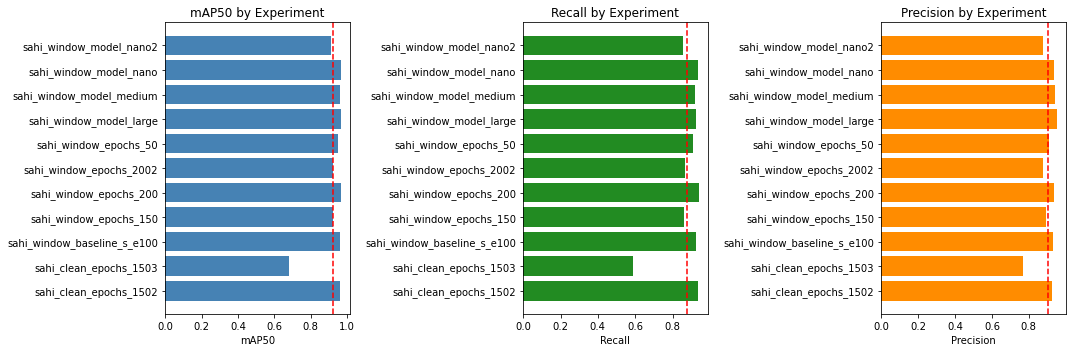

In [36]:
if MATPLOTLIB_AVAILABLE and successful_results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    exp_names = [r['experiment'] for r in successful_results]
    mAP50s = [r['mAP50'] for r in successful_results]
    recalls = [r['recall'] for r in successful_results]
    precisions = [r['precision'] for r in successful_results]
    
    # mAP50 comparison
    axes[0].barh(exp_names, mAP50s, color='steelblue')
    axes[0].set_xlabel('mAP50')
    axes[0].set_title('mAP50 by Experiment')
    axes[0].axvline(x=sum(mAP50s)/len(mAP50s), color='red', linestyle='--', label='Mean')
    
    # Recall comparison
    axes[1].barh(exp_names, recalls, color='forestgreen')
    axes[1].set_xlabel('Recall')
    axes[1].set_title('Recall by Experiment')
    axes[1].axvline(x=sum(recalls)/len(recalls), color='red', linestyle='--', label='Mean')
    
    # Precision comparison
    axes[2].barh(exp_names, precisions, color='darkorange')
    axes[2].set_xlabel('Precision')
    axes[2].set_title('Precision by Experiment')
    axes[2].axvline(x=sum(precisions)/len(precisions), color='red', linestyle='--', label='Mean')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = output_dir / 'experiment_comparison.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")
    
    plt.show()
else:
    print("Skipping plots (matplotlib not available or no successful experiments)")

In [37]:
# SAHI comparison plot
if MATPLOTLIB_AVAILABLE and RUN_SAHI_EVALUATION:
    sahi_results_plot = [r for r in successful_results if r.get('sahi_detections') and r.get('std_detections')]
    
    if sahi_results_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        exp_names = [r['experiment'] for r in sahi_results_plot]
        std_dets = [r['std_detections'] for r in sahi_results_plot]
        sahi_dets = [r['sahi_detections'] for r in sahi_results_plot]
        increases = [r.get('detection_increase', 0) for r in sahi_results_plot]
        
        # Detection counts: Standard vs SAHI
        x = range(len(exp_names))
        width = 0.35
        
        axes[0].bar([i - width/2 for i in x], std_dets, width, label='Standard', color='steelblue')
        axes[0].bar([i + width/2 for i in x], sahi_dets, width, label='SAHI', color='coral')
        axes[0].set_xlabel('Experiment')
        axes[0].set_ylabel('Total Detections')
        axes[0].set_title('Standard vs SAHI Detections')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(exp_names, rotation=45, ha='right')
        axes[0].legend()
        
        # Detection increase
        colors = ['forestgreen' if inc >= 0 else 'red' for inc in increases]
        axes[1].bar(exp_names, increases, color=colors)
        axes[1].set_xlabel('Experiment')
        axes[1].set_ylabel('Additional Detections (SAHI - Standard)')
        axes[1].set_title('SAHI Detection Improvement')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        plt.tight_layout()
        
        # Save figure
        fig_path = output_dir / 'sahi_comparison.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {fig_path}")
        
        plt.show()

## 9. SAHI Metrics & Prediction Visualizations

In [38]:
# Backfills for the experiments I did previously

needs_backfill = [
    r for r in results_summary
    if r.get("status") == "success"
    and r.get("best_model_path")
    and r.get("sahi_mAP50") is None
]

print(f"Experiments needing SAHI metric backfill: {len(needs_backfill)}")
for r in needs_backfill:
    print(f"  - {r['experiment']}")

for r in needs_backfill:
    exp_name = r["experiment"]
    model_path = r["best_model_path"]
    imgsz = r["imgsz"]

    print(f"\nBackfilling: {exp_name}  (imgsz={imgsz})")

    if not Path(model_path).exists():
        print(f"  SKIP — model not found: {model_path}")
        continue

    sahi_m = evaluate_with_sahi_metrics(
        model_path     = model_path,
        val_images_dir = val_images_dir,
        val_labels_dir = val_labels_dir,
        slice_size     = imgsz,
        overlap_ratio  = SAHI_OVERLAP_RATIO,
        conf_thresh    = SAHI_CONFIDENCE_THRESHOLD,
        iou_thresh     = 0.5,
    )

    if sahi_m:
        r["sahi_precision"] = sahi_m["precision"]
        r["sahi_recall"]    = sahi_m["recall"]
        r["sahi_mAP50"]     = sahi_m["mAP50"]
        print(f"  Precision: {sahi_m['precision']:.4f}  "
              f"Recall: {sahi_m['recall']:.4f}  "
              f"mAP50: {sahi_m['mAP50']:.4f}")
    else:
        print(f"  FAILED — evaluate_with_sahi_metrics returned None")

# Persist updated results back to the progress JSON
if needs_backfill:
    save_progress(results_summary, progress_file)
    print(f"\nBackfill complete. Results saved to {progress_file}")
else:
    print("Nothing to backfill — all experiments already have SAHI metrics.")


Experiments needing SAHI metric backfill: 11
  - sahi_clean_epochs_1502
  - sahi_clean_epochs_1503
  - sahi_window_baseline_s_e100
  - sahi_window_epochs_150
  - sahi_window_epochs_200
  - sahi_window_epochs_2002
  - sahi_window_epochs_50
  - sahi_window_model_large
  - sahi_window_model_medium
  - sahi_window_model_nano
  - sahi_window_model_nano2

Backfilling: sahi_clean_epochs_1502  (imgsz=1024)
   Memory cleared.
  Precision: 0.9228  Recall: 0.9501  mAP50: 0.8989

Backfilling: sahi_clean_epochs_1503  (imgsz=1024)
   Memory cleared.
  Precision: 0.8067  Recall: 0.5679  mAP50: 0.5167

Backfilling: sahi_window_baseline_s_e100  (imgsz=1024)
   Memory cleared.
  Precision: 0.9057  Recall: 0.9333  mAP50: 0.8985

Backfilling: sahi_window_epochs_150  (imgsz=1024)
   Memory cleared.
  Precision: 0.8888  Recall: 0.8895  mAP50: 0.8019

Backfilling: sahi_window_epochs_200  (imgsz=1024)
   Memory cleared.
  Precision: 0.9234  Recall: 0.9486  mAP50: 0.9015

Backfilling: sahi_window_epochs_2002  

In [39]:
# ── SAHI metrics summary table ──────────────────────────────────────
sahi_metric_cols = ['experiment', 'imgsz', 'sahi_mAP50', 'sahi_precision',
                    'sahi_recall', 'sahi_detections', 'std_detections',
                    'detection_increase_pct']

if PANDAS_AVAILABLE and results_summary:
    df_all = pd.DataFrame(results_summary)
    available = [c for c in sahi_metric_cols if c in df_all.columns]
    df_sahi_metrics = df_all[available].copy()
    for col in ['sahi_mAP50', 'sahi_precision', 'sahi_recall']:
        if col in df_sahi_metrics.columns:
            df_sahi_metrics[col] = df_sahi_metrics[col].apply(
                lambda x: f"{x:.4f}" if pd.notna(x) and x is not None else "N/A")
    # Sort by sahi_mAP50 descending for easy reading
    if 'sahi_mAP50' in df_sahi_metrics.columns:
        df_sahi_metrics = df_sahi_metrics.sort_values('sahi_mAP50', ascending=False)
    print("SAHI Metrics Summary (sorted by mAP50)")
    print("=" * 100)
    print(df_sahi_metrics.to_string(index=False))
else:
    print("No results loaded — run the experiments or backfill cell first.")


SAHI Metrics Summary (sorted by mAP50)
                 experiment  imgsz sahi_mAP50 sahi_precision sahi_recall
    sahi_window_model_large   1024     0.9028         0.9421      0.9427
     sahi_window_epochs_200   1024     0.9015         0.9234      0.9486
     sahi_window_model_nano   1024     0.9000         0.9203      0.9452
   sahi_window_model_medium   1024     0.8997         0.9170      0.9352
     sahi_clean_epochs_1502   1024     0.8989         0.9228      0.9501
sahi_window_baseline_s_e100   1024     0.8985         0.9057      0.9333
      sahi_window_epochs_50   1024     0.8939         0.8960      0.9201
    sahi_window_epochs_2002   1024     0.8020         0.8716      0.8965
     sahi_window_epochs_150   1024     0.8019         0.8888      0.8895
    sahi_window_model_nano2   1024     0.7966         0.8474      0.8938
     sahi_clean_epochs_1503   1024     0.5167         0.8067      0.5679


Saved: jupiter_inlet_sahi_windowed/sahi_metrics_comparison.png


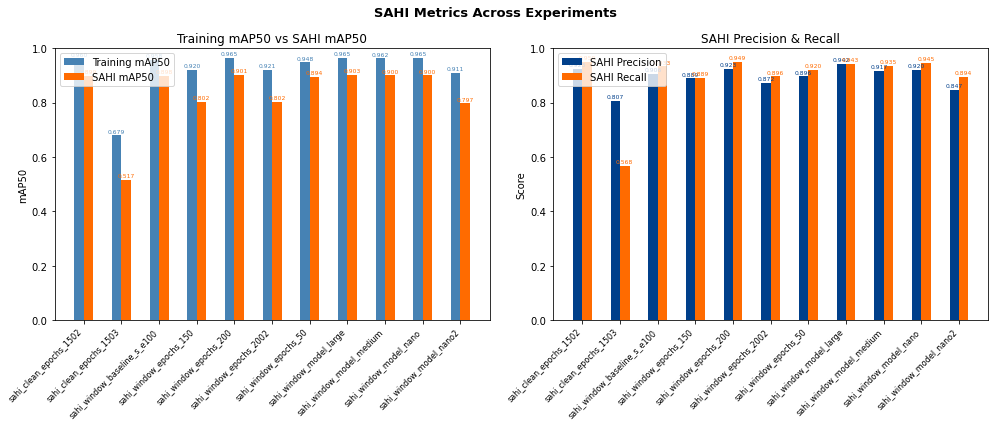

In [40]:
# ── SAHI mAP50 / Precision / Recall bar chart ───────────────────────
if MATPLOTLIB_AVAILABLE and results_summary:
    sahi_rows = [
        r for r in results_summary
        if r.get('status') == 'success'
        and r.get('sahi_mAP50') is not None
    ]
    if not sahi_rows:
        print("No SAHI metrics yet — run the backfill cell above first.")
    else:
        names  = [r['experiment'] for r in sahi_rows]
        s_map  = [r['sahi_mAP50']    for r in sahi_rows]
        s_prec = [r['sahi_precision'] for r in sahi_rows]
        s_rec  = [r['sahi_recall']    for r in sahi_rows]
        t_map  = [r.get('mAP50', 0)   for r in sahi_rows]

        x     = np.arange(len(names))
        width = 0.25

        fig, axes = plt.subplots(1, 2, figsize=(max(14, len(names)*0.9), 6))

        # Left: Training mAP50 vs SAHI mAP50
        axes[0].bar(x - width/2, t_map, width, label='Training mAP50', color='steelblue')
        axes[0].bar(x + width/2, s_map, width, label='SAHI mAP50',     color='#ff6b00')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        axes[0].set_ylabel('mAP50')
        axes[0].set_title('Training mAP50 vs SAHI mAP50')
        axes[0].set_ylim(0, 1.0)
        axes[0].legend()
        for xi, (tm, sm) in enumerate(zip(t_map, s_map)):
            axes[0].text(xi - width/2, tm + 0.01, f"{tm:.3f}", ha='center', fontsize=6, color='steelblue')
            axes[0].text(xi + width/2, sm + 0.01, f"{sm:.3f}", ha='center', fontsize=6, color='#ff6b00')

        # Right: SAHI Precision & Recall
        axes[1].bar(x - width/2, s_prec, width, label='SAHI Precision', color='#003f8a')
        axes[1].bar(x + width/2, s_rec,  width, label='SAHI Recall',    color='#ff6b00')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        axes[1].set_ylabel('Score')
        axes[1].set_title('SAHI Precision & Recall')
        axes[1].set_ylim(0, 1.0)
        axes[1].legend()
        for xi, (sp, sr) in enumerate(zip(s_prec, s_rec)):
            axes[1].text(xi - width/2, sp + 0.01, f"{sp:.3f}", ha='center', fontsize=6, color='#003f8a')
            axes[1].text(xi + width/2, sr + 0.01, f"{sr:.3f}", ha='center', fontsize=6, color='#ff6b00')

        plt.suptitle('SAHI Metrics Across Experiments', fontsize=13, fontweight='bold')
        plt.tight_layout()
        output_dir = Path(BASE_CONFIG['project'])
        output_dir.mkdir(exist_ok=True)
        plt.savefig(output_dir / 'sahi_metrics_comparison.png', dpi=150, bbox_inches='tight')
        print(f"Saved: {output_dir}/sahi_metrics_comparison.png")
        plt.show()


### Visualize GT vs SAHI Predictions

In [41]:


successful = [r for r in results_summary
              if r.get('status') == 'success' and r.get('sahi_mAP50') is not None]

if successful:
    best_exp      = max(successful, key=lambda r: r['sahi_mAP50'])
    BEST_MODEL_PATH = best_exp['best_model_path']
    VIZ_SLICE_SIZE  = best_exp['imgsz']
    print(f"Visualising: {best_exp['experiment']}")
    print(f"  Model : {BEST_MODEL_PATH}")
    print(f"  Slice : {VIZ_SLICE_SIZE}px")
else:
    # Fallback — edit these manually if results_summary is not populated
    BEST_MODEL_PATH = "jupiter_inlet_experiments_v2/796img_baseline_s_640_e100/weights/best.pt"
    VIZ_SLICE_SIZE  = 640
    print("No results found — using fallback path. Edit BEST_MODEL_PATH if needed.")


Visualising: sahi_window_model_large
  Model : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_large/weights/best.pt
  Slice : 1024px


   Figure saved to jupiter_inlet_sahi_windowed/sahi_gt_vs_pred.png


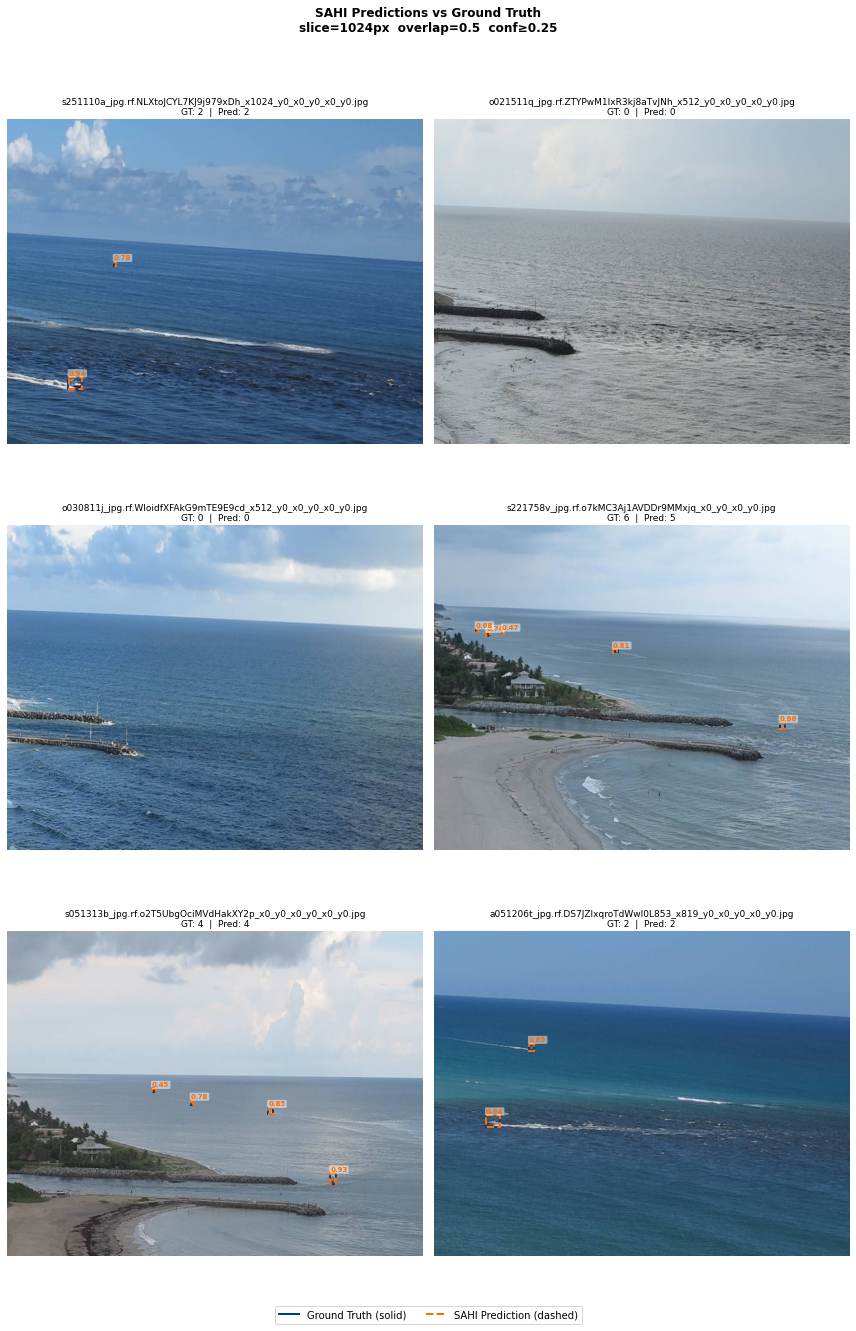

   Memory cleared.


In [42]:
# ── Generate visualizations ──────────────────────────────────────────
output_dir = Path(BASE_CONFIG['project'])
output_dir.mkdir(exist_ok=True)

visualize_sahi_predictions(
    model_path     = BEST_MODEL_PATH,
    val_images_dir = val_images_dir,
    val_labels_dir = val_labels_dir,
    slice_size     = VIZ_SLICE_SIZE,
    overlap_ratio  = SAHI_OVERLAP_RATIO,
    conf_thresh    = SAHI_CONFIDENCE_THRESHOLD,
    n_images       = 6,      # how many val images to show
    seed           = 42,     # change for different random selection
    save_path      = str(output_dir / "sahi_gt_vs_pred.png"),
)


## 10. IoU Threshold Sweep (0.3-0.6)

In [43]:
# ── Configuration ────────────────────────────────────────────────────
successful = [r for r in results_summary
              if r.get("status") == "success" and r.get("sahi_mAP50") is not None]

if successful:
    best_exp        = max(successful, key=lambda r: r["sahi_mAP50"])
    SWEEP_MODEL_PATH  = best_exp["best_model_path"]
    SWEEP_SLICE_SIZE  = best_exp["imgsz"]
    SWEEP_EXP_NAME    = best_exp["experiment"]
    print(f"Running sweep on: {SWEEP_EXP_NAME}")
    print(f"  Model : {SWEEP_MODEL_PATH}")
    print(f"  Slice : {SWEEP_SLICE_SIZE}px")
else:
    # Fallback — edit manually
    SWEEP_MODEL_PATH  = "jupiter_inlet_experiments_v2/796img_imgsz_768/weights/best.pt"
    SWEEP_SLICE_SIZE  = 768
    SWEEP_EXP_NAME    = "796img_imgsz_768"
    print("No results found — using fallback. Edit SWEEP_MODEL_PATH if needed.")

IOU_THRESHOLDS   = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
SWEEP_CONF       = SAHI_CONFIDENCE_THRESHOLD   
SWEEP_OVERLAP    = SAHI_OVERLAP_RATIO           

print(f"\nIoU thresholds to test: {IOU_THRESHOLDS}")
print(f"Conf threshold (fixed): {SWEEP_CONF}")
print(f"Overlap ratio  (fixed): {SWEEP_OVERLAP}")


Running sweep on: sahi_window_model_large
  Model : /blue/bsc4892/aileenlavelle/PBC_Object_Detection/runs/detect/jupiter_inlet_sahi_windowed/sahi_window_model_large/weights/best.pt
  Slice : 1024px

IoU thresholds to test: [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
Conf threshold (fixed): 0.25
Overlap ratio  (fixed): 0.5


In [44]:
# ── Run the sweep ─────────────────────────────────────────────────────
iou_sweep_results = []

header = f"  {'IoU':>6}  {'Precision':>10}  {'Recall':>8}  {'F1':>6}  {'mAP50':>8}  {'Detections':>12}"
print(f"Starting IoU sweep — {len(IOU_THRESHOLDS)} runs\n")
print(header)
print("  " + "-" * 52)

for iou_thresh in IOU_THRESHOLDS:
    m = evaluate_with_sahi_metrics(
        model_path     = SWEEP_MODEL_PATH,
        val_images_dir = val_images_dir,
        val_labels_dir = val_labels_dir,
        slice_size     = SWEEP_SLICE_SIZE,
        overlap_ratio  = SWEEP_OVERLAP,
        conf_thresh    = SWEEP_CONF,
        iou_thresh     = iou_thresh,
    )
    if m:
        f1 = round(2 * m['precision'] * m['recall'] / (m['precision'] + m['recall'] + 1e-9), 4)
        row = {
            "iou_thresh":   iou_thresh,
            "precision":    m["precision"],
            "recall":       m["recall"],
            "f1":           f1,
            "mAP50":        m["mAP50"],
            "detections":   m["total_detections"],
            "time_per_img": m["time_per_image"],
            # Store full PR curve for plotting
            "_recalls":     m.get('_recalls', []),
            "_precisions":  m.get('_precisions', []),
            "_f1_curve":    m.get('_f1_curve', []),
        }
        iou_sweep_results.append(row)
        print(f"  {iou_thresh:>6.2f}  {m['precision']:>10.4f}  "
              f"{m['recall']:>8.4f}  {f1:>6.4f}  {m['mAP50']:>8.4f}  "
              f"{m['total_detections']:>12}")
    else:
        print(f"  {iou_thresh:>6.2f}  FAILED")

print("\nSweep complete.")


Starting IoU sweep — 7 runs

     IoU   Precision    Recall      F1     mAP50    Detections
  ----------------------------------------------------
   Memory cleared.
    0.30      0.9602    0.9607  0.9604    0.9073          5097
   Memory cleared.
    0.35      0.9590    0.9596  0.9593    0.9073          5097
   Memory cleared.
    0.40      0.9566    0.9572  0.9569    0.9061          5097
   Memory cleared.
    0.45      0.9494    0.9499  0.9496    0.9041          5097
   Memory cleared.
    0.50      0.9421    0.9427  0.9424    0.9028          5097
   Memory cleared.
    0.55      0.9249    0.9254  0.9251    0.8964          5097
   Memory cleared.
    0.60      0.8958    0.8963  0.8960    0.8034          5097

Sweep complete.


In [45]:
# ── Results table ─────────────────────────────────────────────────────
if PANDAS_AVAILABLE and iou_sweep_results:
    df_iou = pd.DataFrame(iou_sweep_results)
    # Highlight the best row for each metric
    best_map_idx  = df_iou["mAP50"].idxmax()
    best_prec_idx = df_iou["precision"].idxmax()
    best_rec_idx  = df_iou["recall"].idxmax()

    # Add F1 column
    df_iou['f1'] = (2 * df_iou['precision'] * df_iou['recall']
                    / (df_iou['precision'] + df_iou['recall'] + 1e-9)).round(4)
    best_f1_idx   = df_iou['f1'].idxmax()

    print(f"\nIoU Sweep Results — {SWEEP_EXP_NAME}")
    print("=" * 75)
    print(df_iou[['iou_thresh','precision','recall','f1','mAP50','detections']]
          .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("=" * 75)
    print(f"  Best mAP50     → IoU = {df_iou.loc[best_map_idx,  'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_map_idx,  'mAP50']:.4f})")
    print(f"  Best Precision → IoU = {df_iou.loc[best_prec_idx, 'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_prec_idx, 'precision']:.4f})")
    print(f"  Best Recall    → IoU = {df_iou.loc[best_rec_idx,  'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_rec_idx,  'recall']:.4f})")
    print(f"  Best F1        → IoU = {df_iou.loc[best_f1_idx,   'iou_thresh']:.2f}  "
          f"({df_iou.loc[best_f1_idx,   'f1']:.4f})")
else:
    print("No sweep results to display.")



IoU Sweep Results — sahi_window_model_large
 iou_thresh  precision  recall     f1  mAP50  detections
     0.3000     0.9602  0.9607 0.9604 0.9073        5097
     0.3500     0.9590  0.9596 0.9593 0.9073        5097
     0.4000     0.9566  0.9572 0.9569 0.9061        5097
     0.4500     0.9494  0.9499 0.9496 0.9041        5097
     0.5000     0.9421  0.9427 0.9424 0.9028        5097
     0.5500     0.9249  0.9254 0.9251 0.8964        5097
     0.6000     0.8958  0.8963 0.8960 0.8034        5097
  Best mAP50     → IoU = 0.30  (0.9073)
  Best Precision → IoU = 0.30  (0.9602)
  Best Recall    → IoU = 0.30  (0.9607)
  Best F1        → IoU = 0.30  (0.9604)


Saved: jupiter_inlet_sahi_windowed/iou_sweep.png


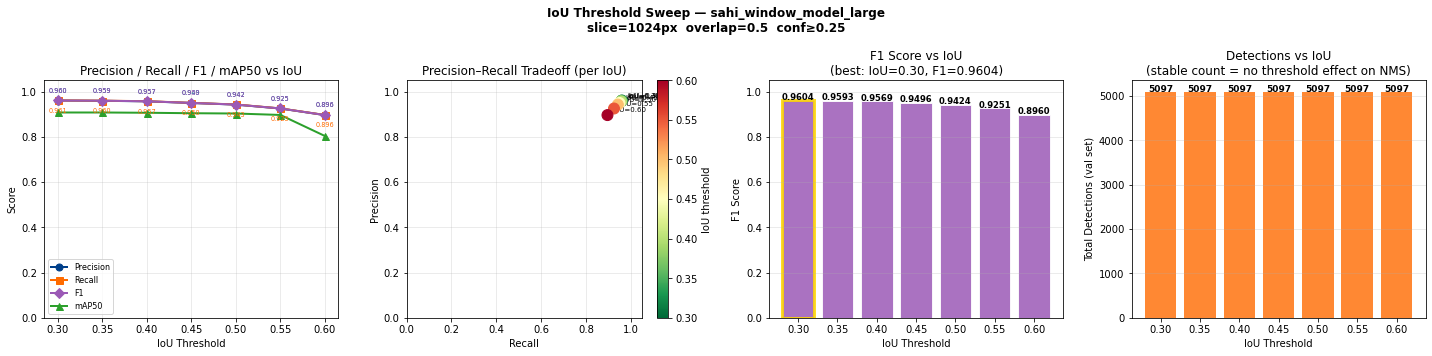

Saved: jupiter_inlet_sahi_windowed/pr_curves.png


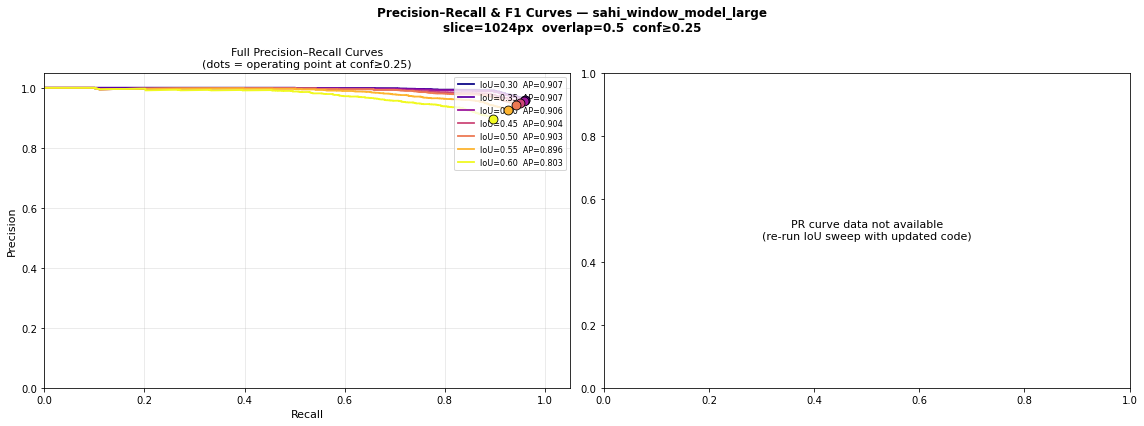

In [46]:
# ── Plot sweep results + PR curves ─────────────────────────────────
import numpy as np

if MATPLOTLIB_AVAILABLE and iou_sweep_results:
    df_iou = pd.DataFrame(iou_sweep_results) if PANDAS_AVAILABLE else None
    ious   = [r['iou_thresh']  for r in iou_sweep_results]
    precs  = [r['precision']   for r in iou_sweep_results]
    recs   = [r['recall']      for r in iou_sweep_results]
    f1s    = [r.get('f1', 2*r['precision']*r['recall']/(r['precision']+r['recall']+1e-9))
              for r in iou_sweep_results]
    maps   = [r['mAP50']       for r in iou_sweep_results]
    dets   = [r['detections']  for r in iou_sweep_results]

    # ── FIGURE 1: Metrics vs IoU (4-panel, now with F1) ──────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # Panel 1: P / R / F1 / mAP50 vs IoU
    ax = axes[0]
    ax.plot(ious, precs, 'o-', color='#003f8a', linewidth=2, markersize=7, label='Precision')
    ax.plot(ious, recs,  's-', color='#ff6b00', linewidth=2, markersize=7, label='Recall')
    ax.plot(ious, f1s,   'D-', color='#9b59b6', linewidth=2, markersize=7, label='F1')
    ax.plot(ious, maps,  '^-', color='#2ca02c', linewidth=2, markersize=7, label='mAP50')
    for iou, p, r, f, m in zip(ious, precs, recs, f1s, maps):
        ax.annotate(f'{p:.3f}', (iou, p), textcoords='offset points', xytext=(0, 8),  fontsize=6.5, color='#003f8a', ha='center')
        ax.annotate(f'{r:.3f}', (iou, r), textcoords='offset points', xytext=(0,-12), fontsize=6.5, color='#ff6b00', ha='center')
        ax.annotate(f'{f:.3f}', (iou, f), textcoords='offset points', xytext=(0, 8),  fontsize=6.5, color='#9b59b6', ha='center')
    ax.set_xlabel('IoU Threshold'); ax.set_ylabel('Score')
    ax.set_title('Precision / Recall / F1 / mAP50 vs IoU')
    ax.set_ylim(0, 1.05); ax.set_xticks(ious); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Panel 2: P-R tradeoff scatter (one point per IoU threshold)
    ax = axes[1]
    sc = ax.scatter(recs, precs, c=ious, cmap='RdYlGn_r', s=120, zorder=5)
    ax.plot(recs, precs, '--', color='grey', linewidth=1, zorder=4)
    for iou, p, r in zip(ious, precs, recs):
        ax.annotate(f'IoU={iou:.2f}', (r, p), textcoords='offset points', xytext=(6, 3), fontsize=7)
    plt.colorbar(sc, ax=ax, label='IoU threshold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title('Precision–Recall Tradeoff (per IoU)')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

    # Panel 3: F1 vs IoU bar chart
    ax = axes[2]
    iou_strs = [f'{i:.2f}' for i in ious]
    bars = ax.bar(iou_strs, f1s, color='#9b59b6', alpha=0.85, edgecolor='white')
    best_f1_idx = int(np.argmax(f1s))
    bars[best_f1_idx].set_edgecolor('gold'); bars[best_f1_idx].set_linewidth(3)
    for xi, (iou, f) in enumerate(zip(ious, f1s)):
        ax.text(xi, f + 0.005, f'{f:.4f}', ha='center', fontsize=8.5, fontweight='bold')
    ax.set_xlabel('IoU Threshold'); ax.set_ylabel('F1 Score')
    ax.set_title(f'F1 Score vs IoU\n(best: IoU={ious[best_f1_idx]:.2f}, F1={f1s[best_f1_idx]:.4f})')
    ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3, axis='y')

    # Panel 4: Detections vs IoU
    ax = axes[3]
    ax.bar(iou_strs, dets, color='#ff6b00', alpha=0.8)
    for xi, d in enumerate(dets):
        ax.text(xi, d + 2, str(d), ha='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('IoU Threshold'); ax.set_ylabel('Total Detections (val set)')
    ax.set_title('Detections vs IoU\n(stable count = no threshold effect on NMS)')
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle(
        f'IoU Threshold Sweep — {SWEEP_EXP_NAME}\n'
        f'slice={SWEEP_SLICE_SIZE}px  overlap={SWEEP_OVERLAP}  conf≥{SWEEP_CONF}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    output_dir = Path(BASE_CONFIG['project'])
    output_dir.mkdir(exist_ok=True)
    plt.savefig(output_dir / 'iou_sweep.png', dpi=150, bbox_inches='tight')
    print(f'Saved: {output_dir}/iou_sweep.png')
    plt.show()

    # ── FIGURE 2: Full PR curves for each IoU threshold ──────────────
    # Uses the _recalls / _precisions arrays stored per IoU run
    has_curves = any(r.get('_recalls') for r in iou_sweep_results)
    if has_curves:
        cmap_pr = plt.cm.get_cmap('plasma', len(iou_sweep_results))
        fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

        # Left: full PR curves
        ax = axes2[0]
        for i, row in enumerate(iou_sweep_results):
            r_arr = np.array(row.get('_recalls', []))
            p_arr = np.array(row.get('_precisions', []))
            if len(r_arr) == 0:
                continue
            color = cmap_pr(i)
            ax.plot(r_arr, p_arr, color=color, linewidth=1.8,
                    label=f"IoU={row['iou_thresh']:.2f}  AP={row['mAP50']:.3f}")
            # Mark the operating point at conf_thresh
            ax.scatter([row['recall']], [row['precision']], color=color, s=80, zorder=6,
                       marker='o', edgecolors='black', linewidth=0.8)
        ax.set_xlabel('Recall', fontsize=11); ax.set_ylabel('Precision', fontsize=11)
        ax.set_title('Full Precision–Recall Curves\n(dots = operating point at conf≥0.25)', fontsize=11)
        ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.fill_between([], [], alpha=0)   # empty fill for visual spacing

        # Right: F1 vs score threshold (for the best IoU)
        ax = axes2[1]
        best_iou_row = max(iou_sweep_results, key=lambda r: r['mAP50'])
        f1_curve = np.array(best_iou_row.get('_f1_curve', []))
        scores   = np.array(best_iou_row.get('_scores', []))
        if len(f1_curve) > 0 and len(scores) > 0:
            ax.plot(scores, f1_curve, color='#9b59b6', linewidth=2)
            best_f1_pos = int(np.argmax(f1_curve))
            ax.axvline(scores[best_f1_pos], color='gold', linestyle='--', linewidth=1.5,
                       label=f'Best F1={f1_curve[best_f1_pos]:.4f} @ conf={scores[best_f1_pos]:.3f}')
            ax.scatter([scores[best_f1_pos]], [f1_curve[best_f1_pos]],
                       color='gold', s=100, zorder=6, edgecolors='black')
            ax.set_xlabel('Confidence Score', fontsize=11)
            ax.set_ylabel('F1 Score', fontsize=11)
            ax.set_title(f'F1 vs Confidence Threshold\n(best IoU={best_iou_row["iou_thresh"]:.2f})', fontsize=11)
            ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        else:
            ax.text(0.5, 0.5, 'PR curve data not available\n(re-run IoU sweep with updated code)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=11)

        plt.suptitle(
            f'Precision–Recall & F1 Curves — {SWEEP_EXP_NAME}\n'
            f'slice={SWEEP_SLICE_SIZE}px  overlap={SWEEP_OVERLAP}  conf≥{SWEEP_CONF}',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.savefig(output_dir / 'pr_curves.png', dpi=150, bbox_inches='tight')
        print(f'Saved: {output_dir}/pr_curves.png')
        plt.show()
    else:
        print('Note: Full PR curves not available — re-run the IoU sweep with the updated evaluate_with_sahi_metrics() to generate them.')
else:
    print('No sweep results to plot.')


Best IoU threshold: 0.30
  Precision: 0.9602
  Recall:    0.9607
  mAP50:     0.9073

Generating sample visualizations at IoU=0.30...
   Figure saved to jupiter_inlet_sahi_windowed/sahi_best_iou_0.30.png


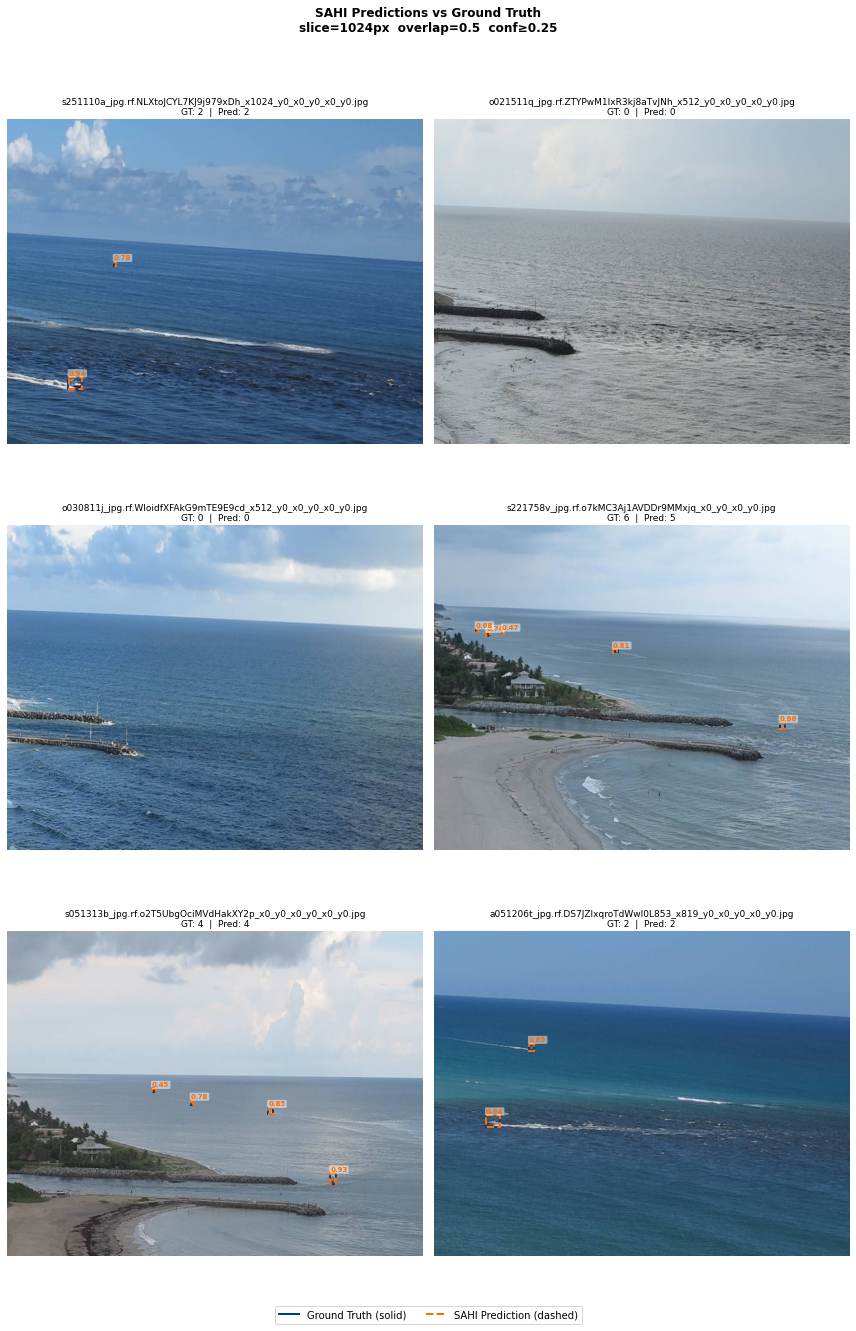

   Memory cleared.


In [47]:
# ── Visualize best IoU on sample images ──────────────────────────────
# Re-runs visualization with the IoU that gave the best mAP50
if iou_sweep_results:
    best_row    = max(iou_sweep_results, key=lambda r: r["mAP50"])
    best_iou    = best_row["iou_thresh"]
    print(f"Best IoU threshold: {best_iou:.2f}")
    print(f"  Precision: {best_row['precision']:.4f}")
    print(f"  Recall:    {best_row['recall']:.4f}")
    print(f"  mAP50:     {best_row['mAP50']:.4f}")
    print(f"\nGenerating sample visualizations at IoU={best_iou:.2f}...")

    output_dir = Path(BASE_CONFIG["project"])
    visualize_sahi_predictions(
        model_path     = SWEEP_MODEL_PATH,
        val_images_dir = val_images_dir,
        val_labels_dir = val_labels_dir,
        slice_size     = SWEEP_SLICE_SIZE,
        overlap_ratio  = SWEEP_OVERLAP,
        conf_thresh    = SWEEP_CONF,
        n_images       = 6,
        seed           = 42,
        save_path      = str(output_dir / f"sahi_best_iou_{best_iou:.2f}.png"),
    )
else:
    print("Run the sweep cells above first.")
